# ***Evaluating Bias in Readmission Prediction Models: Demographic Disparities in Diabetic Patient Outcomes***

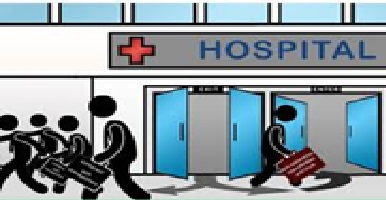

# Environment setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import the required libraries -
# numpy, pandas for data manipulation,
# matplotlib, seaborn for visualization,
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Set the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# Set the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library for scaling
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.utils import resample
from scipy.stats import ttest_rel
from scipy.stats import chi2_contingency

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Load Data and perform Basic checks

In [3]:
# Read the data from diabetic data csv file
DiabData_df = pd.read_csv(
    "/content/drive/MyDrive/Capstone project QM640/diabetic_data.csv",
    na_values=["?"],   # only treat '?' as missing
    keep_default_na=False
)

In [4]:
# Create a copy of original data set as back-up
DiabData_backupcopy = DiabData_df.copy()

In [5]:
# Use the shape function to get the number of rows and columns in the data set
DiabData_df.shape

(101766, 50)

In [6]:
# Find the datatypes of various columns in this data set using the 'info()' function
DiabData_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
# View the first 5 rows from the data set
DiabData_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
# View the last 5 rows from the data set
DiabData_df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,51,0,16,0,0,0,250.13,291,458,9,None,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,33,3,18,0,0,1,560,276,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,1,0,0,38,590,296,13,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,None,None,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,13,3,3,0,0,0,530,530,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [9]:
# Find missing values in data - by using the isnull() function and summing the count of null values
DiabData_df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [10]:
# Find duplicate values in data - by using the duplicated () function and sum the count of null values
DiabData_df.duplicated().sum()

np.int64(0)

In [11]:
# Find the statistical summary of numerical data using the describe() function
DiabData_df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.00000,165201645.62298,102640295.98346,12522.00000,84961194.00000,152388987.00000,230270887.50000,443867222.00000
patient_nbr,101766.00000,54330400.69495,38696359.34653,135.00000,23413221.00000,45505143.00000,87545949.75000,189502619.00000
admission_type_id,101766.00000,2.02401,1.44540,1.00000,1.00000,1.00000,3.00000,8.00000
discharge_disposition_id,101766.00000,3.71564,5.28017,1.00000,1.00000,1.00000,4.00000,28.00000
admission_source_id,101766.00000,5.75444,4.06408,1.00000,1.00000,7.00000,7.00000,25.00000
time_in_hospital,101766.00000,4.39599,2.98511,1.00000,2.00000,4.00000,6.00000,14.00000
num_lab_procedures,101766.00000,43.09564,19.67436,1.00000,31.00000,44.00000,57.00000,132.00000
num_procedures,101766.00000,1.33973,1.70581,0.00000,0.00000,1.00000,2.00000,6.00000
num_medications,101766.00000,16.02184,8.12757,1.00000,10.00000,15.00000,20.00000,81.00000
number_outpatient,101766.00000,0.36936,1.26727,0.00000,0.00000,0.00000,0.00000,42.00000


# Pre-process data - Feature Exclusion

In [12]:
# Replace '?' with NaN

DiabData_df = DiabData_df.replace('?', np.nan)

In [13]:
# Drop coumns not relevant

# -------------------------------
# Columns to DROP
# -------------------------------

# Identifier columns (not useful for modeling)
id_cols = [
    'encounter_id',
    'patient_nbr',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id'
]

# High-missing / low-value columns
high_missing_cols = [
    'weight',
    'payer_code',
    'medical_specialty'
]

# Diagnosis codes (complex, high cardinality)
diag_cols = [
    'diag_1',
    'diag_2',
    'diag_3'
]

# Medication columns (22 columns)
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

# Combine all columns to drop
cols_to_drop = id_cols + high_missing_cols + diag_cols + medication_cols

# Drop columns safely (ignore if any column not present)
DiabData_df = DiabData_df.drop(columns=cols_to_drop, errors='ignore')

# -------------------------------
# Columns to KEEP explicitly (sanity check)
# -------------------------------

print("Remaining columns:")
print(DiabData_df.columns.tolist())

print("\nShape after dropping columns:")
print(DiabData_df.shape)

Remaining columns:
['race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'readmitted']

Shape after dropping columns:
(101766, 17)


# Exploratory Data Analysis

In [14]:
# Function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=10)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

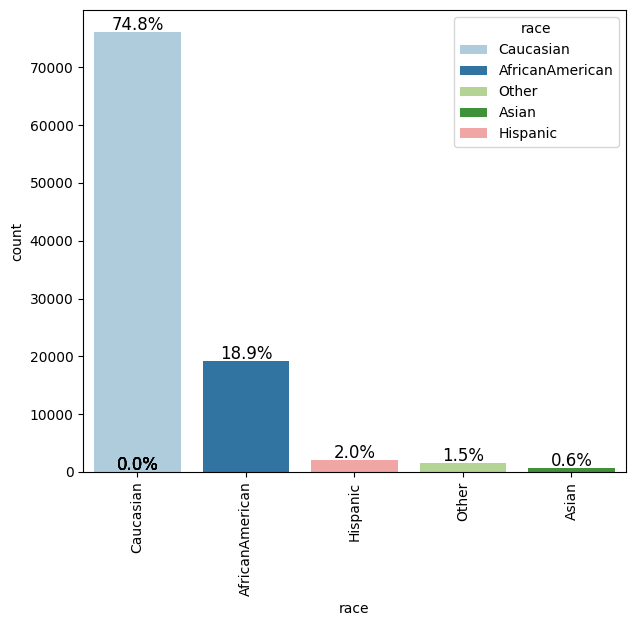

,count
race,
Caucasian,76099
AfricanAmerican,19210
Hispanic,2037
Other,1506
Asian,641


In [15]:
# "Race" distribution
labeled_barplot(DiabData_df, "race", perc=True)
DiabData_df['race'].value_counts()

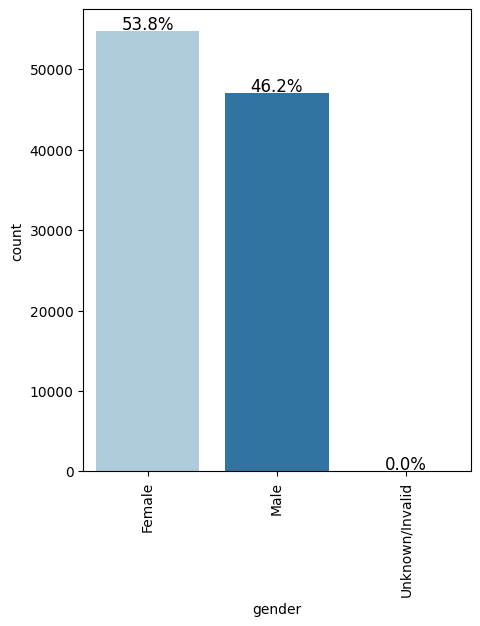

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [16]:
# "Gender" distribution
labeled_barplot(DiabData_df, "gender", perc=True)
DiabData_df['gender'].value_counts()

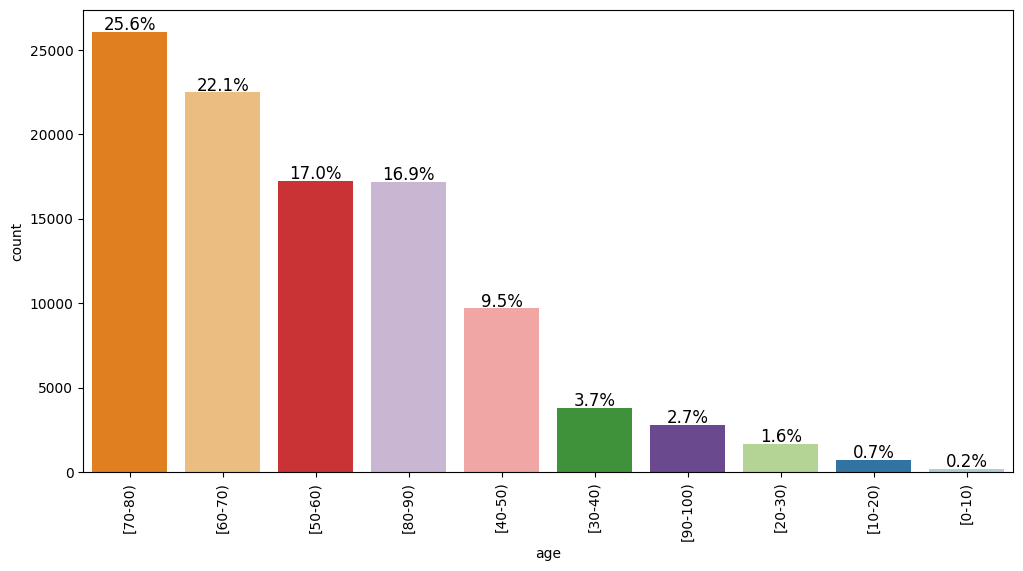

,count
age,
[70-80),26068
[60-70),22483
[50-60),17256
[80-90),17197
[40-50),9685
[30-40),3775
[90-100),2793
[20-30),1657
[10-20),691


In [17]:
# "Age" distribution
labeled_barplot(DiabData_df, "age", perc=True)
DiabData_df['age'].value_counts()

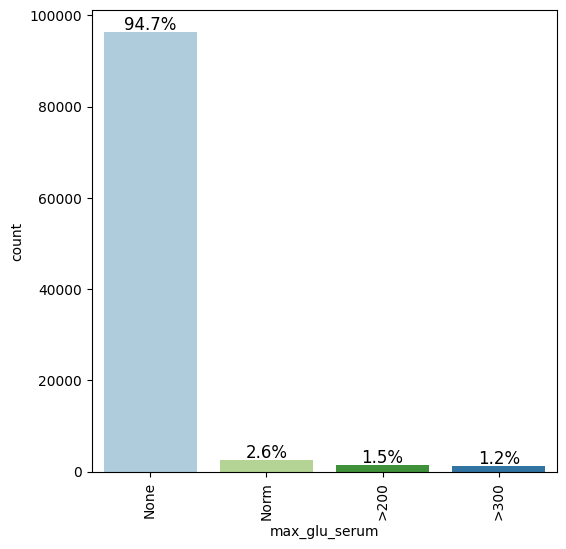

,count
max_glu_serum,
None,96420
Norm,2597
>200,1485
>300,1264


In [18]:
# "Glucose serum test" distribution
labeled_barplot(DiabData_df, "max_glu_serum", perc=True)
DiabData_df['max_glu_serum'].value_counts()

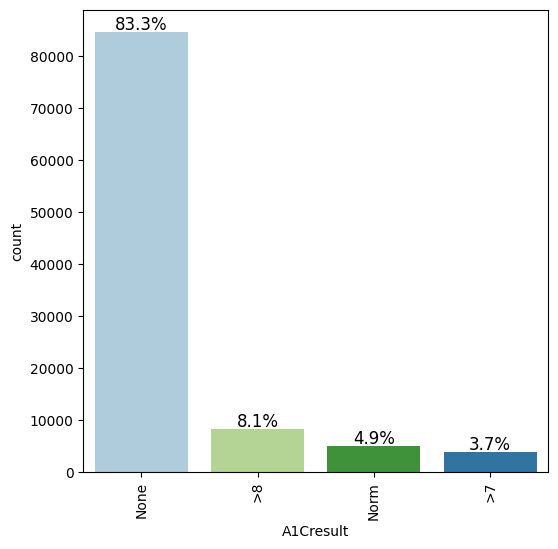

,count
A1Cresult,
None,84748
>8,8216
Norm,4990
>7,3812


In [19]:
# "A1C result" distribution
labeled_barplot(DiabData_df, "A1Cresult", perc=True)
DiabData_df['A1Cresult'].value_counts()

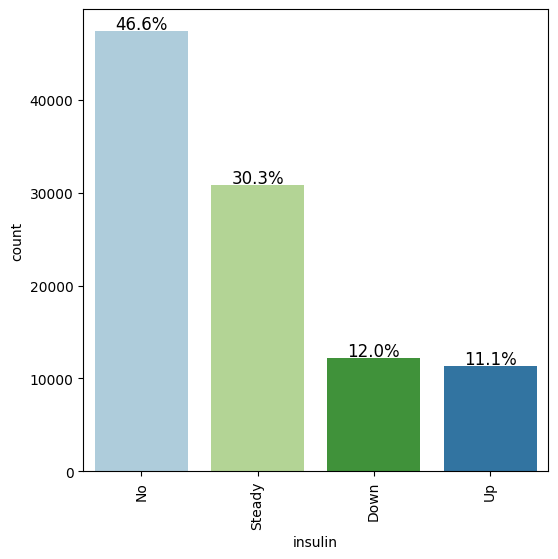

,count
insulin,
No,47383
Steady,30849
Down,12218
Up,11316


In [20]:
# "Insulin" distribution
labeled_barplot(DiabData_df, "insulin", perc=True)
DiabData_df['insulin'].value_counts()

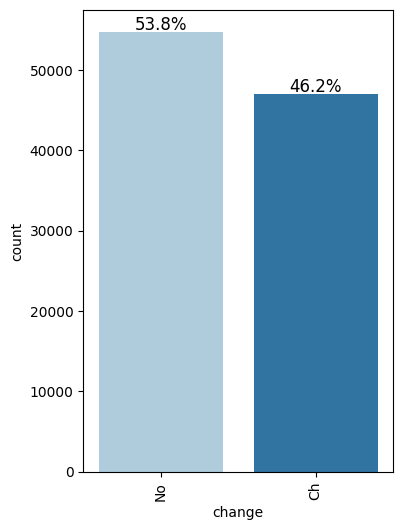

,count
change,
No,54755
Ch,47011


In [21]:
# "Change of medication" distribution
labeled_barplot(DiabData_df, "change", perc=True)
DiabData_df['change'].value_counts()

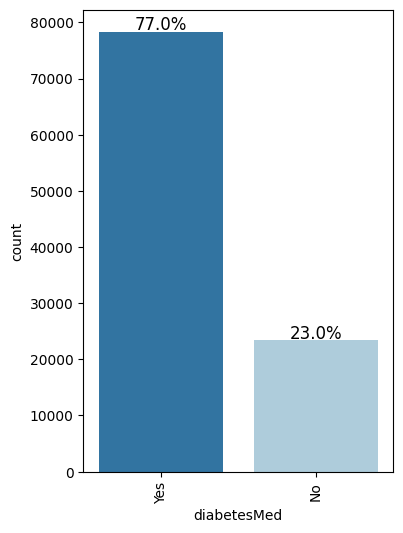

,count
diabetesMed,
Yes,78363
No,23403


In [22]:
# "Diabetes medication" distribution
labeled_barplot(DiabData_df, "diabetesMed", perc=True)
DiabData_df['diabetesMed'].value_counts()

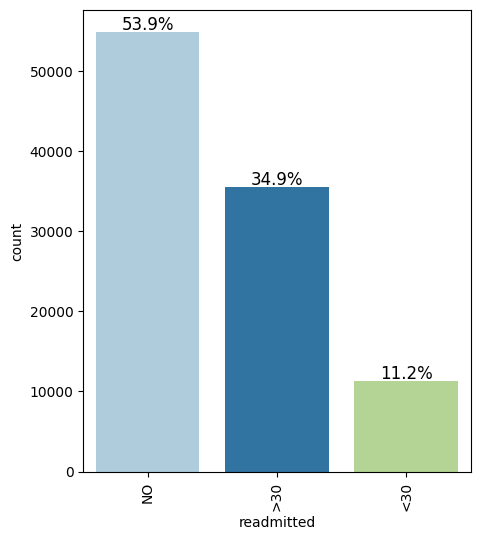

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [23]:
# "Readmitted" distribution
labeled_barplot(DiabData_df, "readmitted", perc=True)
DiabData_df['readmitted'].value_counts()

In [24]:
# Using the shape function to get the number of rows and columns in the data set
DiabData_df.shape

(101766, 17)

In [25]:
# Finding the datatypes of various columns in this data set using the 'info()' function
DiabData_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   race                99493 non-null   object
 1   gender              101766 non-null  object
 2   age                 101766 non-null  object
 3   time_in_hospital    101766 non-null  int64 
 4   num_lab_procedures  101766 non-null  int64 
 5   num_procedures      101766 non-null  int64 
 6   num_medications     101766 non-null  int64 
 7   number_outpatient   101766 non-null  int64 
 8   number_emergency    101766 non-null  int64 
 9   number_inpatient    101766 non-null  int64 
 10  number_diagnoses    101766 non-null  int64 
 11  max_glu_serum       101766 non-null  object
 12  A1Cresult           101766 non-null  object
 13  insulin             101766 non-null  object
 14  change              101766 non-null  object
 15  diabetesMed         101766 non-null  object
 16  re

In [26]:
# Find missing values in data - by using the isnull() function and summing the count of null values
DiabData_df.isnull().sum()

,0
race,2273
gender,0
age,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0
number_inpatient,0


In [27]:
# Find the statistical summary of numerical data using the describe() function
DiabData_df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.00000,4.39599,2.98511,1.00000,2.00000,4.00000,6.00000,14.00000
num_lab_procedures,101766.00000,43.09564,19.67436,1.00000,31.00000,44.00000,57.00000,132.00000
num_procedures,101766.00000,1.33973,1.70581,0.00000,0.00000,1.00000,2.00000,6.00000
num_medications,101766.00000,16.02184,8.12757,1.00000,10.00000,15.00000,20.00000,81.00000
number_outpatient,101766.00000,0.36936,1.26727,0.00000,0.00000,0.00000,0.00000,42.00000
number_emergency,101766.00000,0.19784,0.93047,0.00000,0.00000,0.00000,0.00000,76.00000
number_inpatient,101766.00000,0.63557,1.26286,0.00000,0.00000,0.00000,1.00000,21.00000
number_diagnoses,101766.00000,7.42261,1.93360,1.00000,6.00000,8.00000,9.00000,16.00000


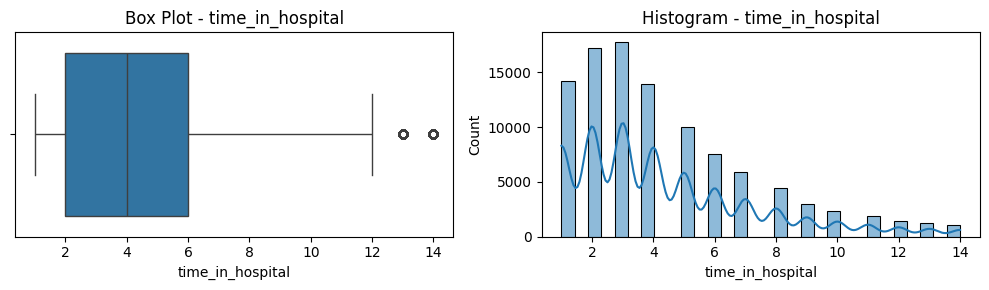

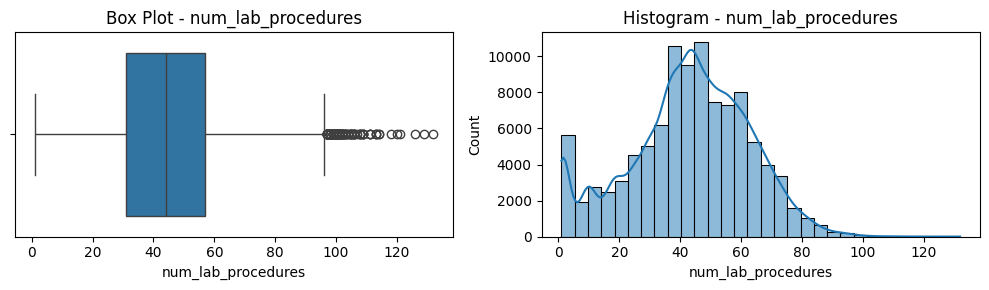

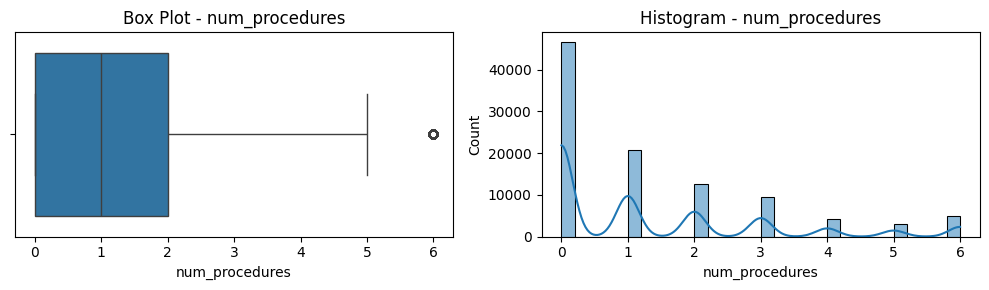

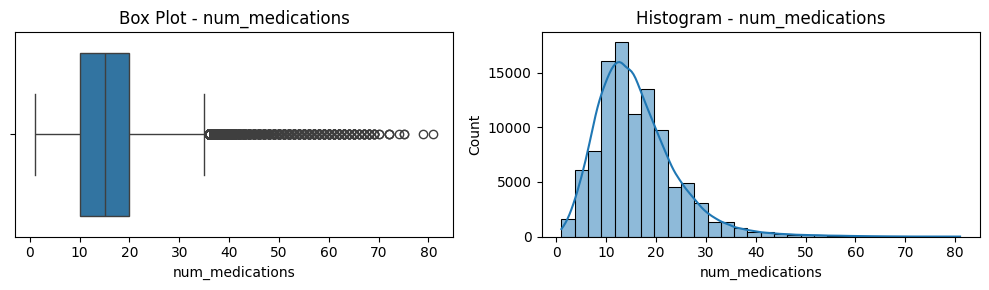

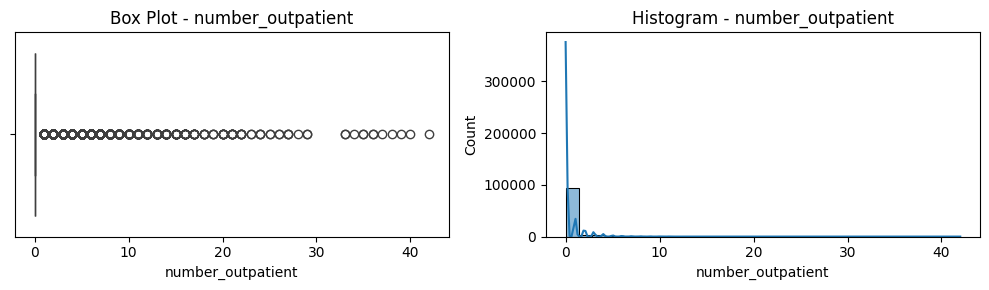

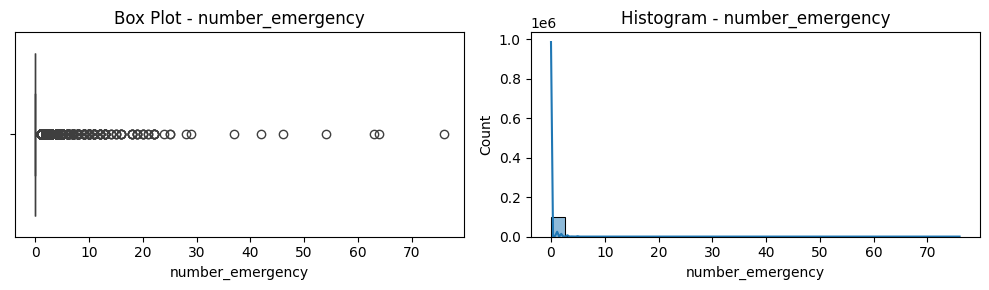

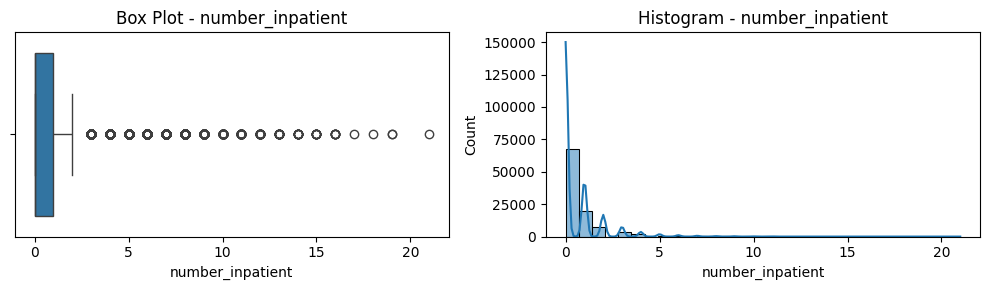

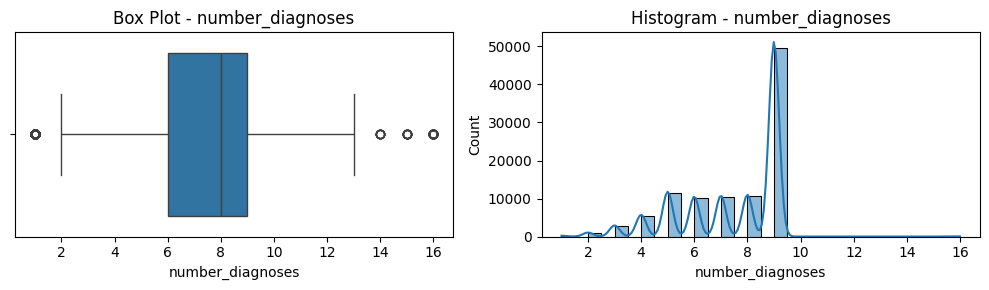

In [28]:
# get the relevant numeric columns
numeric_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    # Box plot
    sns.boxplot(x=DiabData_df[col], ax=axes[0])
    axes[0].set_title(f'Box Plot - {col}')

    # Histogram
    sns.histplot(DiabData_df[col], bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram - {col}')

    plt.tight_layout()
    plt.show()

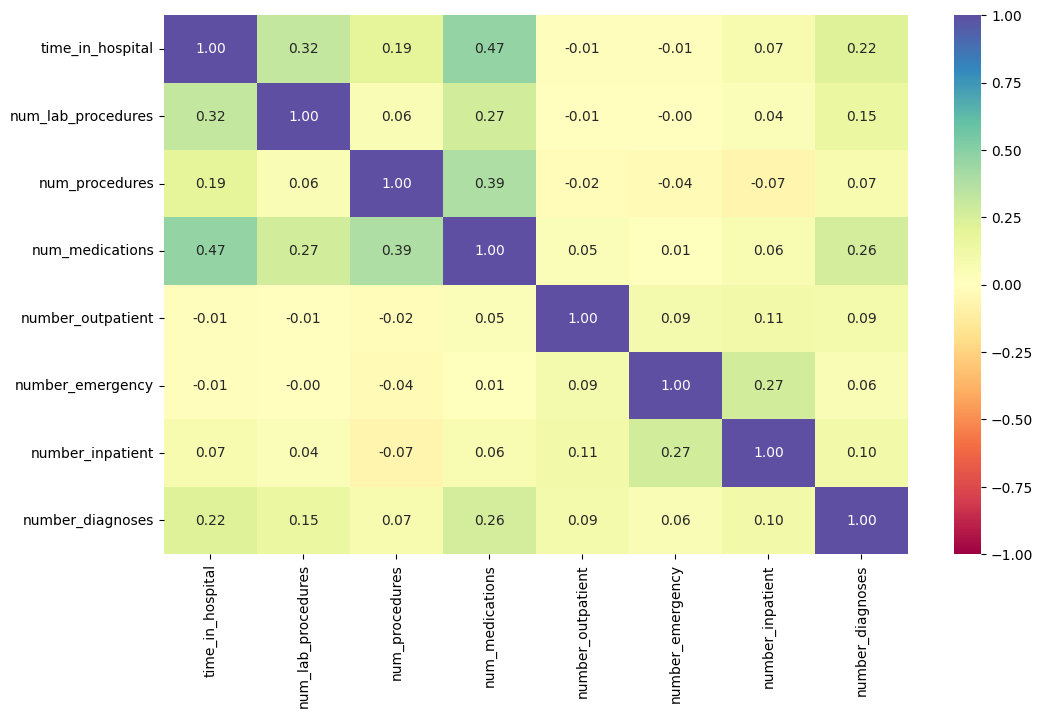

In [29]:
plt.figure(figsize=(12, 7))
sns.heatmap(DiabData_df[numeric_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

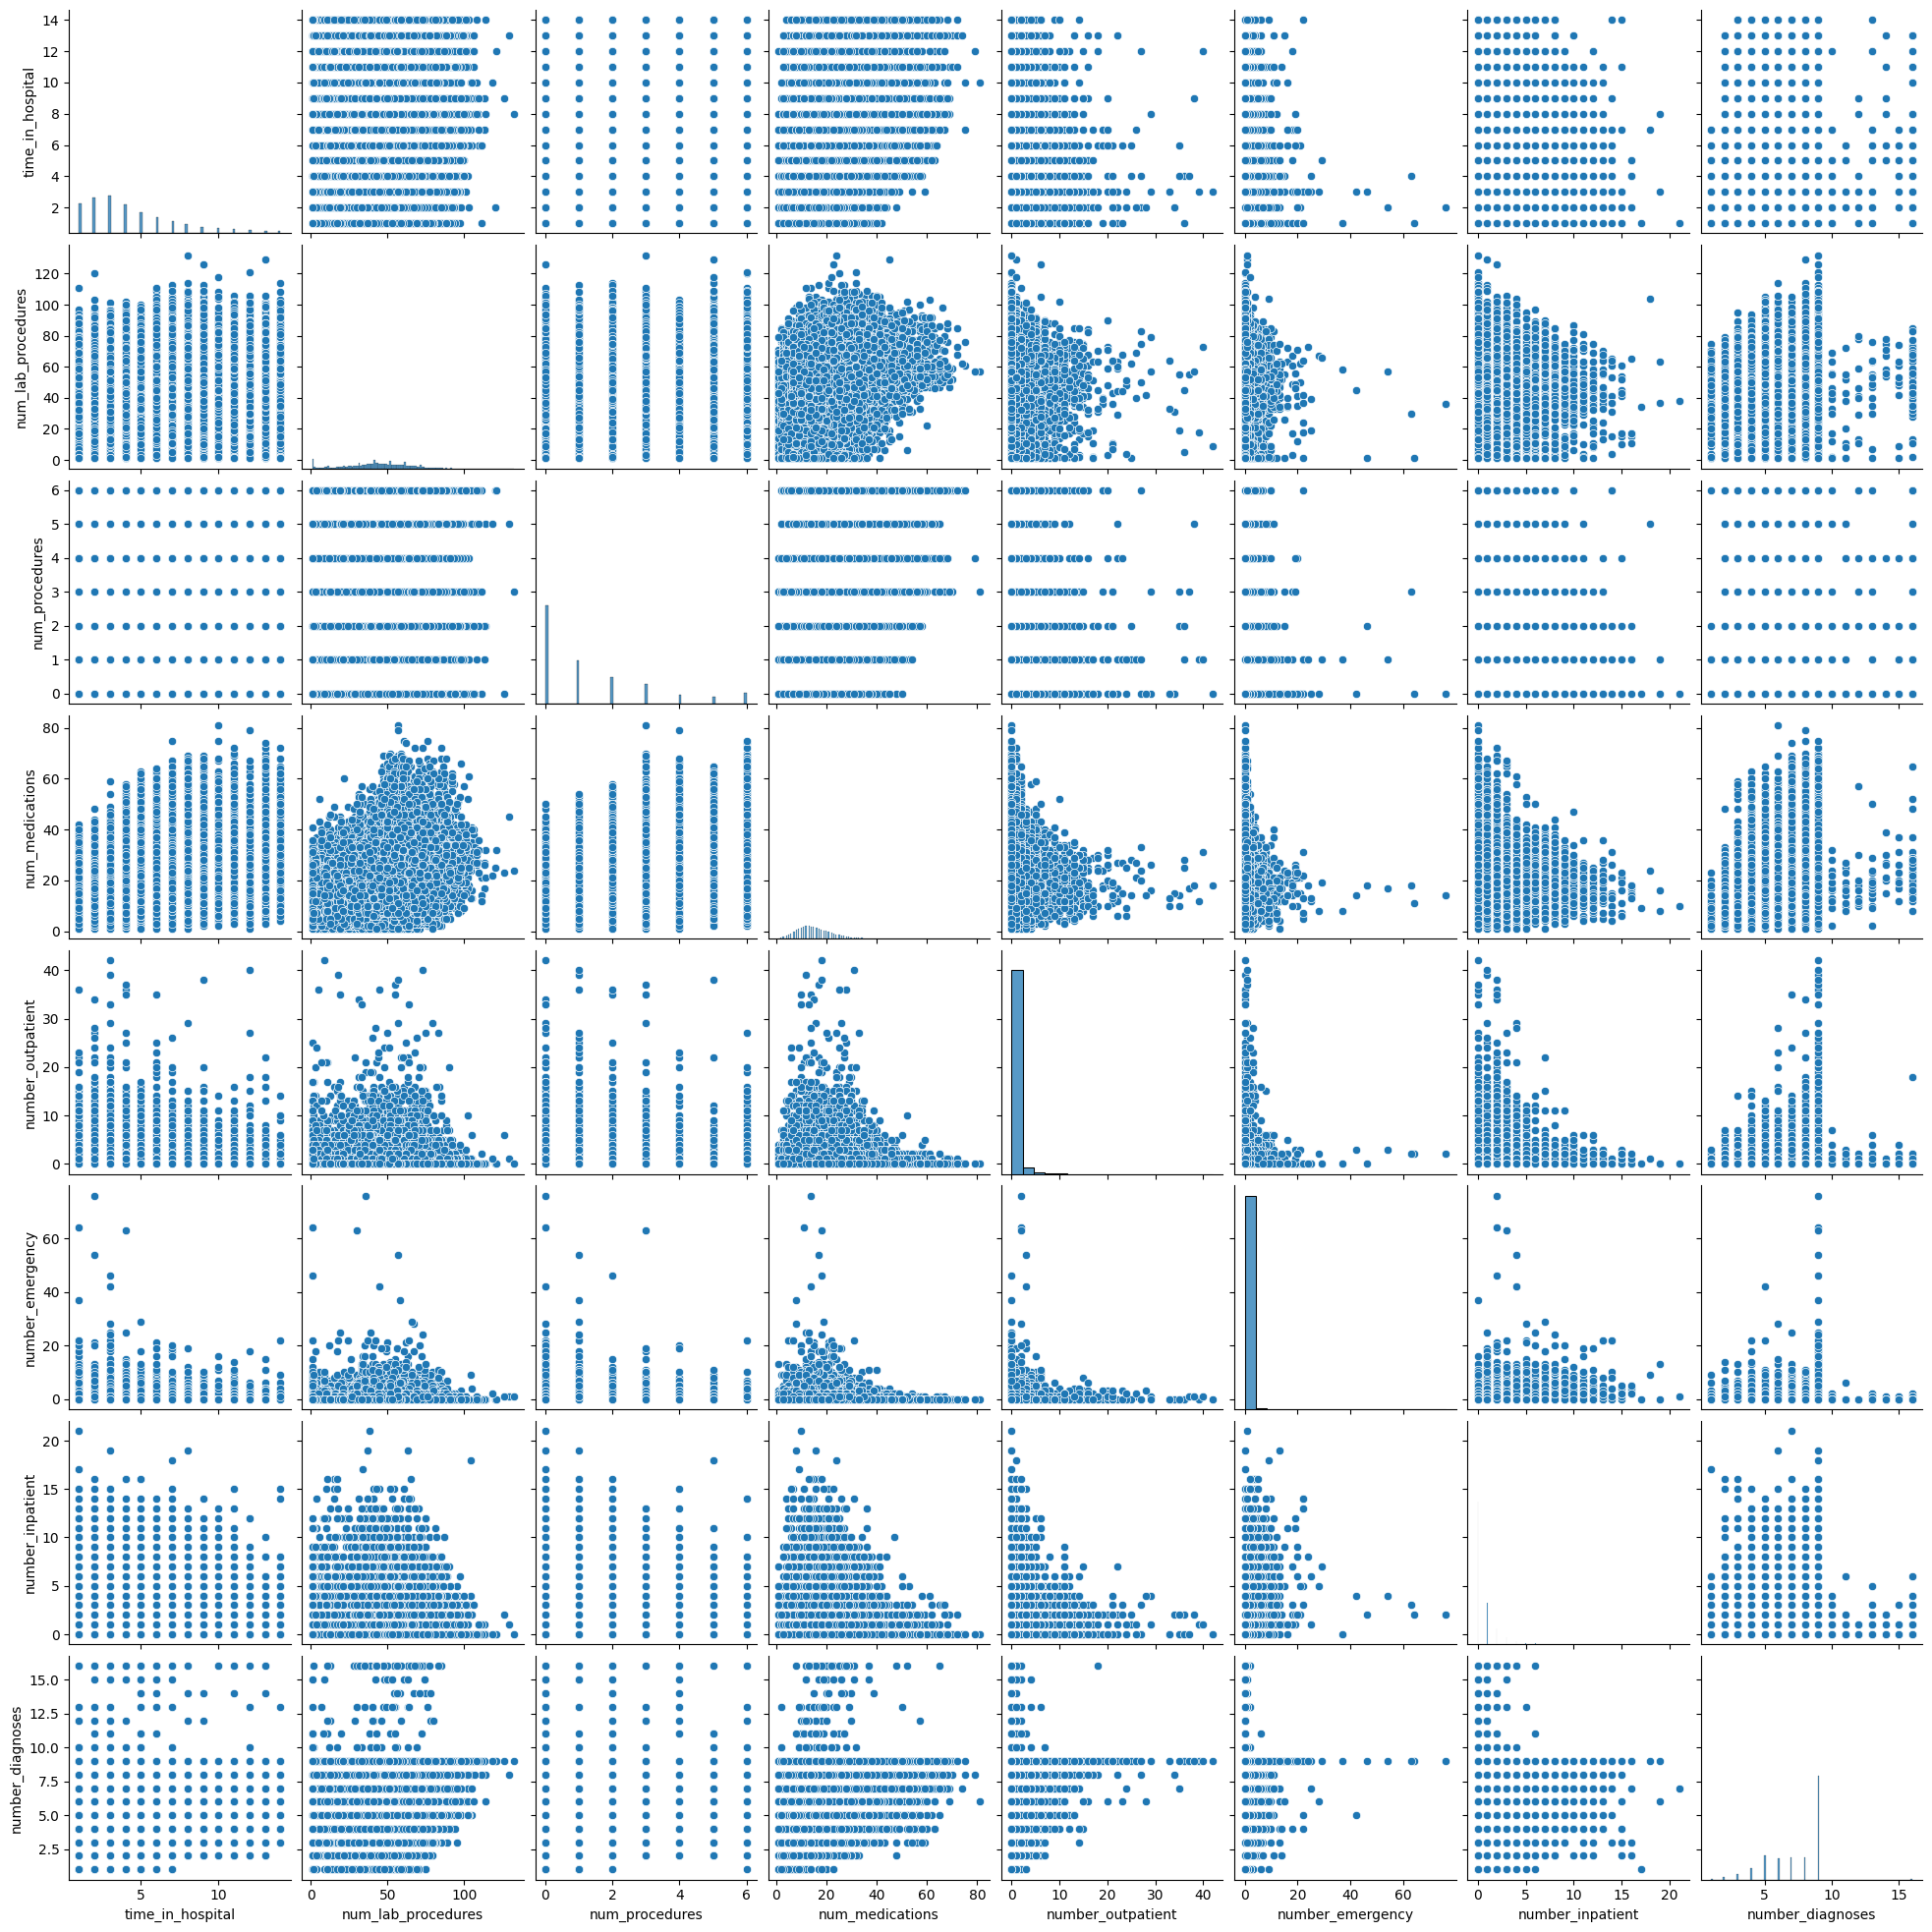

In [30]:
sns.pairplot(data=DiabData_df, vars=[
      'time_in_hospital',
      'num_lab_procedures',
      'num_procedures',
      'num_medications',
      'number_outpatient',
      'number_emergency',
      'number_inpatient',
      'number_diagnoses',
      ]);

# Prepare Data for Modelling

In [31]:
# Create age group mapping
def map_age_group(age):
    if age in ['[60-70)', '[70-80)']:
        return 'Senior'
    else:
        return 'Upto60'

DiabData_df['age_group'] = DiabData_df['age'].apply(map_age_group)

# Check distribution
print(DiabData_df['age_group'].value_counts())

age_group
Upto60    53215
Senior    48551
Name: count, dtype: int64


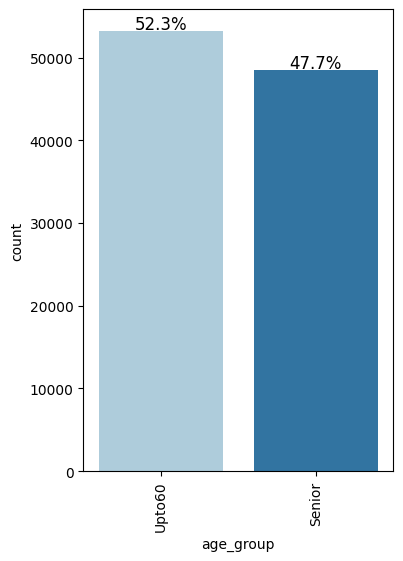

,count
age_group,
Upto60,53215
Senior,48551


In [32]:
# "Age Group" distribution
labeled_barplot(DiabData_df, "age_group", perc=True)
DiabData_df['age_group'].value_counts()

In [33]:
# Create race group mapping
def group_race(x):
    if x == 'Caucasian':
        return 'Caucasian'
    elif x == 'AfricanAmerican':
        return 'AfricanAmerican'
    else:
        return 'Other_Minority'

DiabData_df['race_group'] = DiabData_df['race'].apply(group_race)

print(DiabData_df['race_group'].value_counts())

race_group
Caucasian          76099
AfricanAmerican    19210
Other_Minority      6457
Name: count, dtype: int64


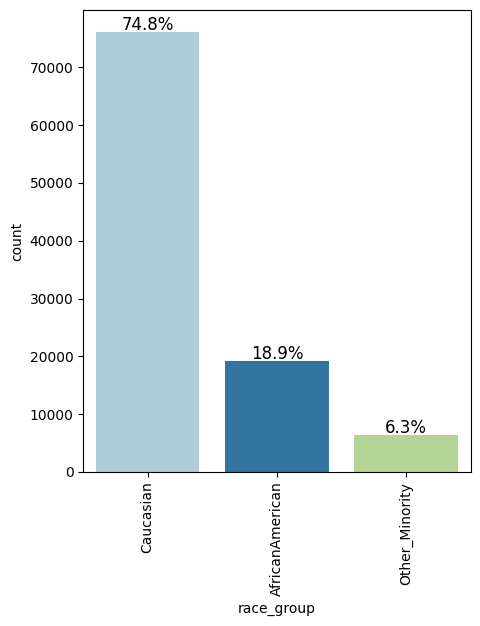

,count
race_group,
Caucasian,76099
AfricanAmerican,19210
Other_Minority,6457


In [34]:
# "Race Group" distribution
labeled_barplot(DiabData_df, "race_group", perc=True)
DiabData_df['race_group'].value_counts()

In [35]:
# encode Target variables

DiabData_df['readmitted_binary'] = DiabData_df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

# Check distribution
print(DiabData_df['readmitted_binary'].value_counts())

readmitted_binary
0    54864
1    46902
Name: count, dtype: int64


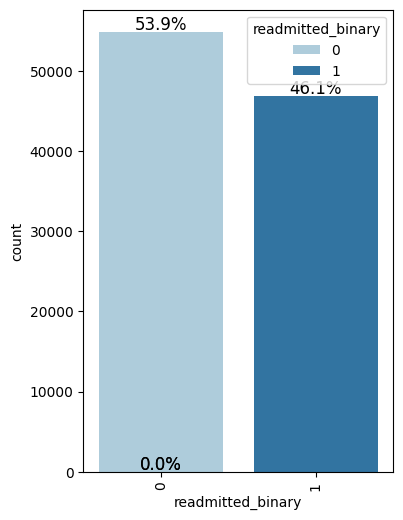

,count
readmitted_binary,
0,54864
1,46902


In [36]:
# "Readmitted" distribution
labeled_barplot(DiabData_df, "readmitted_binary", perc=True)
DiabData_df['readmitted_binary'].value_counts()

In [37]:
# drop original age column
DiabData_df = DiabData_df.drop(columns=['age'])
# Drop original race column
DiabData_df = DiabData_df.drop(columns=['race'])
# drop original target column
DiabData_df = DiabData_df.drop(columns=['readmitted'])

In [38]:
race_series = DiabData_df['race_group'].copy()
age_series = DiabData_df['age_group'].copy()
gender_series = DiabData_df['gender'].copy()

In [39]:
DiabData_df

,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,age_group,race_group,readmitted_binary
0,Female,1,41,0,1,0,0,0,1,None,None,No,No,No,Upto60,Caucasian,0
1,Female,3,59,0,18,0,0,0,9,None,None,Up,Ch,Yes,Upto60,Caucasian,1
2,Female,2,11,5,13,2,0,1,6,None,None,No,No,Yes,Upto60,AfricanAmerican,0
3,Male,2,44,1,16,0,0,0,7,None,None,Up,Ch,Yes,Upto60,Caucasian,0
4,Male,1,51,0,8,0,0,0,5,None,None,Steady,Ch,Yes,Upto60,Caucasian,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,Male,3,51,0,16,0,0,0,9,None,>8,Down,Ch,Yes,Senior,AfricanAmerican,1
101762,Female,5,33,3,18,0,0,1,9,None,None,Steady,No,Yes,Upto60,AfricanAmerican,0
101763,Male,1,53,0,9,1,0,0,13,None,None,Down,Ch,Yes,Senior,Caucasian,0
101764,Female,10,45,2,21,0,0,1,9,None,None,Up,Ch,Yes,Upto60,Caucasian,0


In [40]:
# Define Features & Target
X = DiabData_df.drop(columns=['readmitted_binary'])
X_encoded = pd.get_dummies(X, drop_first=True)
y = DiabData_df['readmitted_binary']

In [41]:
X_encoded.shape

(101766, 24)

In [42]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   time_in_hospital           101766 non-null  int64
 1   num_lab_procedures         101766 non-null  int64
 2   num_procedures             101766 non-null  int64
 3   num_medications            101766 non-null  int64
 4   number_outpatient          101766 non-null  int64
 5   number_emergency           101766 non-null  int64
 6   number_inpatient           101766 non-null  int64
 7   number_diagnoses           101766 non-null  int64
 8   gender_Male                101766 non-null  bool 
 9   gender_Unknown/Invalid     101766 non-null  bool 
 10  max_glu_serum_>300         101766 non-null  bool 
 11  max_glu_serum_None         101766 non-null  bool 
 12  max_glu_serum_Norm         101766 non-null  bool 
 13  A1Cresult_>8               101766 non-null  bool 
 14  A1Cr

In [43]:
X_encoded.head(8)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,gender_Male,gender_Unknown/Invalid,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,age_group_Upto60,race_group_Caucasian,race_group_Other_Minority
0,1,41,0,1,0,0,0,1,False,False,False,True,False,False,True,False,True,False,False,True,False,True,True,False
1,3,59,0,18,0,0,0,9,False,False,False,True,False,False,True,False,False,False,True,False,True,True,True,False
2,2,11,5,13,2,0,1,6,False,False,False,True,False,False,True,False,True,False,False,True,True,True,False,False
3,2,44,1,16,0,0,0,7,True,False,False,True,False,False,True,False,False,False,True,False,True,True,True,False
4,1,51,0,8,0,0,0,5,True,False,False,True,False,False,True,False,False,True,False,False,True,True,True,False
5,3,31,6,16,0,0,0,9,True,False,False,True,False,False,True,False,False,True,False,True,True,True,True,False
6,4,70,1,21,0,0,0,7,True,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False
7,5,73,0,12,0,0,0,8,True,False,False,True,False,False,True,False,True,False,False,True,True,False,True,False


In [44]:
y.shape

(101766,)

In [45]:
# Train-Test Split with straified split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [46]:
# --------------------------------------------------
# Scale only the original numeric columns
# --------------------------------------------------

numeric_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Keep only numeric columns that are actually present
numeric_cols = [col for col in numeric_cols if col in X_train.columns]

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaled columns:", numeric_cols)
print(X_train[numeric_cols].head())

Scaled columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
25118           0.20287             1.16401        -0.19949         -0.37063   
63601          -0.13190            -0.00331         0.97173          0.86104   
19781          -0.46667            -1.01837        -0.19949          0.61471   
94149          -0.46667             0.75799        -0.78509          0.98421   
68161          -0.13190             0.96100        -0.19949         -0.49379   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
25118           -0.29167          -0.21325          -0.50299          -0.21711  
63601            0.49898           0.86642           0.28910           0.81732  
19781            2.87092           0.86642           0.28910          -2.28598  
94149           -0

# Common Functions across RQ1 and RQ2

In [48]:

def train_and_predict_models(X_train, X_test, y_train, y_test, source_df):
    """
    Train the 3 models once and return prediction results dataframes
    with subgroup columns reattached.
    """

    # Reattach subgroup columns from original dataframe
    demographics = pd.DataFrame({
        'gender': source_df.loc[X_test.index, 'gender'].values,
        'age_group': source_df.loc[X_test.index, 'age_group'].values,
        'race_group': source_df.loc[X_test.index, 'race_group'].values
    }, index=X_test.index)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42)
    }

    results_by_model = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results = demographics.copy()
        results['actual'] = y_test.values
        results['predicted'] = y_pred
        results['correct'] = (results['actual'] == results['predicted']).astype(int)

        results_by_model[model_name] = results

    return results_by_model

# Research question #1 : Accuracy across groups

In [49]:
def run_rq1_test(results_df, group_col):
    """
    Run RQ1 accuracy comparison for one demographic variable.
    Returns summary table, contingency table, and p-value.
    """

    # Accuracy summary
    summary = results_df.groupby(group_col)['correct'].agg(['sum', 'count'])
    summary['accuracy'] = summary['sum'] / summary['count']

    # Contingency table: group vs correct/incorrect
    contingency = pd.crosstab(results_df[group_col], results_df['correct'])

    # Chi-square test
    chi2, p_value, _, _ = chi2_contingency(contingency)

    return summary, contingency, p_value

In [50]:
def run_rq1_all_models(results_by_model):
    """
    Run RQ1 for all 3 models across gender, age_group, and race_group.
    Returns:
    - nested results dictionary
    - summary dataframe of p-values
    """

    demographic_groups = ['gender', 'age_group', 'race_group']
    rq1_outputs = {}
    summary_rows = []

    for model_name, results_df in results_by_model.items():
        rq1_outputs[model_name] = {}

        for group_col in demographic_groups:
            summary, contingency, p_value = run_rq1_test(results_df, group_col)

            rq1_outputs[model_name][group_col] = {
                'summary': summary,
                'contingency': contingency,
                'p_value': p_value
            }

            summary_rows.append({
                'Model': model_name,
                'Demographic Group': group_col,
                'p-value': p_value
            })

    summary_df = pd.DataFrame(summary_rows)

    return rq1_outputs, summary_df

In [51]:
# Train all 3 models once and get predictions
results_by_model = train_and_predict_models(
    X_train, X_test, y_train, y_test, DiabData_df
)

# Run RQ1 across all models and demographic groups
rq1_outputs, rq1_pvalue_summary = run_rq1_all_models(results_by_model)

# View p-value summary
print(rq1_pvalue_summary)

                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.21522
1  Logistic Regression         age_group  0.00000
2  Logistic Regression        race_group  0.03570
3        Random Forest            gender  0.15862
4        Random Forest         age_group  0.00000
5        Random Forest        race_group  0.00005
6    Gradient Boosting            gender  0.81544
7    Gradient Boosting         age_group  0.00000
8    Gradient Boosting        race_group  0.00123


In [52]:
rq1_pvalue_pivot = rq1_pvalue_summary.pivot(
    index='Model',
    columns='Demographic Group',
    values='p-value'
)

print(rq1_pvalue_pivot)

Demographic Group    age_group  gender  race_group
Model                                             
Gradient Boosting      0.00000 0.81544     0.00123
Logistic Regression    0.00000 0.21522     0.03570
Random Forest          0.00000 0.15862     0.00005


In [53]:
def print_rq1_results(rq1_outputs, model_name, group_col):
    obj = rq1_outputs[model_name][group_col]

    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Demographic Group: {group_col}")
    print("=" * 60)

    print("\nSummary (Accuracy Table):")
    print(obj['summary'].to_string())

    print("\nContingency Table (Correct vs Incorrect):")
    print(obj['contingency'].to_string())

    print(f"\nChi-square p-value: {obj['p_value']:.6f}")
    print("=" * 60)

In [54]:
print_rq1_results(rq1_outputs, 'Logistic Regression', 'gender')
print_rq1_results(rq1_outputs, 'Logistic Regression', 'race_group')
print_rq1_results(rq1_outputs, 'Logistic Regression', 'age_group')

Model: Logistic Regression
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6734  10922   0.61655
Male    5896   9432   0.62511

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4188  6734
Male     3536  5896

Chi-square p-value: 0.215219
Model: Logistic Regression
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2345   3791   0.61857
Caucasian        9427  15251   0.61812
Other_Minority    858   1312   0.65396

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1446  2345
Caucasian        5824  9427
Other_Minority    454   858

Chi-square p-value: 0.035705
Model: Logistic Regression
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior

In [55]:
print_rq1_results(rq1_outputs, 'Random Forest', 'gender')
print_rq1_results(rq1_outputs, 'Random Forest', 'race_group')
print_rq1_results(rq1_outputs, 'Random Forest', 'age_group')

Model: Random Forest
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6646  10922   0.60850
Male    5647   9432   0.59871

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4276  6646
Male     3785  5647

Chi-square p-value: 0.158619
Model: Random Forest
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2329   3791   0.61435
Caucasian        9103  15251   0.59688
Other_Minority    861   1312   0.65625

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1462  2329
Caucasian        6148  9103
Other_Minority    451   861

Chi-square p-value: 0.000048
Model: Random Forest
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior     5665   9743  

In [56]:
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'gender')
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'race_group')
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'age_group')

Model: Gradient Boosting
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6825  10922   0.62489
Male    5878   9432   0.62320

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4097  6825
Male     3554  5878

Chi-square p-value: 0.815440
Model: Gradient Boosting
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2403   3791   0.63387
Caucasian        9427  15251   0.61812
Other_Minority    873   1312   0.66540

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1388  2403
Caucasian        5824  9427
Other_Minority    439   873

Chi-square p-value: 0.001230
Model: Gradient Boosting
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior     5

# Research question #2 : False Negative Rate Disparities

In [57]:
def run_rq2_test(results_df, group_col):
    """
    Run RQ2 false negative rate comparison for one demographic variable.

    Logic:
    - Restrict analysis to actual positive cases only
    - Among these, compare False Negative vs True Positive counts across groups
    - Compute FNR per group
    - Apply chi-square test on contingency table
    """

    # Keep only actual positives
    pos_df = results_df[results_df['actual'] == 1].copy()

    # Define FN and TP indicators
    pos_df['FN'] = (pos_df['predicted'] == 0).astype(int)
    pos_df['TP'] = (pos_df['predicted'] == 1).astype(int)

    # Summary table
    summary = pos_df.groupby(group_col)['FN'].agg(['sum', 'count'])
    summary['FNR'] = summary['sum'] / summary['count']

    # Contingency table: group vs predicted class among actual positives
    contingency = pd.crosstab(pos_df[group_col], pos_df['predicted'])

    # Ensure both columns exist for clean interpretation
    contingency = contingency.reindex(columns=[0, 1], fill_value=0)
    contingency.columns = ['False_Negative', 'True_Positive']

    # Chi-square test
    chi2, p_value, _, _ = chi2_contingency(contingency)

    return summary, contingency, p_value

In [58]:
def run_rq2_all_models(results_by_model):
    """
    Run RQ2 for all models across gender, age_group, and race_group.

    Returns:
    - nested results dictionary
    - summary dataframe of p-values
    """

    demographic_groups = ['gender', 'age_group', 'race_group']
    rq2_outputs = {}
    summary_rows = []

    for model_name, results_df in results_by_model.items():
        rq2_outputs[model_name] = {}

        for group_col in demographic_groups:
            summary, contingency, p_value = run_rq2_test(results_df, group_col)

            rq2_outputs[model_name][group_col] = {
                'summary': summary,
                'contingency': contingency,
                'p_value': p_value
            }

            summary_rows.append({
                'Model': model_name,
                'Demographic Group': group_col,
                'p-value': p_value
            })

    summary_df = pd.DataFrame(summary_rows)

    return rq2_outputs, summary_df

In [59]:
results_by_model = train_and_predict_models(
    X_train, X_test, y_train, y_test, DiabData_df
)

In [60]:
# Run RQ2 across all models and demographic groups
rq2_outputs, rq2_pvalue_summary = run_rq2_all_models(results_by_model)
# View p-value summary
print(rq2_pvalue_summary)

                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.00000
1  Logistic Regression         age_group  0.00022
2  Logistic Regression        race_group  0.00000
3        Random Forest            gender  0.00000
4        Random Forest         age_group  0.52874
5        Random Forest        race_group  0.00000
6    Gradient Boosting            gender  0.00000
7    Gradient Boosting         age_group  0.41847
8    Gradient Boosting        race_group  0.00000


In [61]:
def print_rq2_results(rq2_outputs, model_name, group_col):
    obj = rq2_outputs[model_name][group_col]

    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Demographic Group: {group_col}")
    print("=" * 60)

    print("\nSummary (False Negative Rate Table):")
    print(obj['summary'].to_string())

    print("\nContingency Table (False Negatives vs True Positives):")
    print(obj['contingency'].to_string())

    print(f"\nChi-square p-value: {obj['p_value']:.6f}")
    print("=" * 60)

In [62]:
print_rq2_results(rq2_outputs, 'Logistic Regression', 'gender')
print_rq2_results(rq2_outputs, 'Logistic Regression', 'age_group')
print_rq2_results(rq2_outputs, 'Logistic Regression', 'race_group')

Model: Logistic Regression
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2998   5219 0.57444
Male    2607   4162 0.62638

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2998           2221
Male              2607           1555

Chi-square p-value: 0.000000
Model: Logistic Regression
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2665   4608 0.57834
Upto60     2940   4773 0.61596

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2665           1943
Upto60               2940           1833

Chi-square p-value: 0.000221
Model: Logistic Regression
Demographic Group: race_group

Summary (False Negative Rate Tabl

In [63]:
print_rq2_results(rq2_outputs, 'Random Forest', 'gender')
print_rq2_results(rq2_outputs, 'Random Forest', 'age_group')
print_rq2_results(rq2_outputs, 'Random Forest', 'race_group')

Model: Random Forest
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2389   5219 0.45775
Male    2132   4162 0.51225

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2389           2830
Male              2132           2030

Chi-square p-value: 0.000000
Model: Random Forest
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2205   4608 0.47852
Upto60     2316   4773 0.48523

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2205           2403
Upto60               2316           2457

Chi-square p-value: 0.528743
Model: Random Forest
Demographic Group: race_group

Summary (False Negative Rate Table):
              

In [64]:
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'gender')
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'age_group')
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'race_group')


Model: Gradient Boosting
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2664   5219 0.51044
Male    2334   4162 0.56079

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2664           2555
Male              2334           1828

Chi-square p-value: 0.000001
Model: Gradient Boosting
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2435   4608 0.52843
Upto60     2563   4773 0.53698

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2435           2173
Upto60               2563           2210

Chi-square p-value: 0.418471
Model: Gradient Boosting
Demographic Group: race_group

Summary (False Negative Rate Table):
  

# Common functions across RQ3 and RQ4

In [66]:

# --------------------------------------------------
# Core helpers
# --------------------------------------------------

def compute_fnr_gap(df, group_col, pred_col='predicted'):
    pos = df[df['actual'] == 1].copy()

    if pos.empty:
        return np.nan

    fnr = pos.groupby(group_col)[pred_col].apply(lambda x: (x == 0).mean())
    fnr = fnr.dropna()

    if len(fnr) < 2:
        return np.nan

    return fnr.max() - fnr.min()


def prepare_split(X_encoded, y, source_df, numeric_cols, random_state, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    scaler = StandardScaler()
    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    demographics = pd.DataFrame({
        'gender': source_df.loc[X_test.index, 'gender'].values,
        'age_group': source_df.loc[X_test.index, 'age_group'].values,
        'race_group': source_df.loc[X_test.index, 'race_group'].values
    }, index=X_test.index)

    return X_train, X_test, y_train, y_test, demographics


def build_results_df(y_test, y_pred, demographics, pred_col_name):
    results = demographics.copy()
    results['actual'] = y_test.values
    results[pred_col_name] = y_pred
    return results


def compute_all_fnr_gaps(results_df, pred_col):
    return {
        'gender': compute_fnr_gap(results_df, 'gender', pred_col),
        'age': compute_fnr_gap(results_df, 'age_group', pred_col),
        'race': compute_fnr_gap(results_df, 'race_group', pred_col)
    }


def rebalance_training_data(X_train, y_train, random_state):
    train_df = X_train.copy()
    train_df['target'] = y_train.values

    majority = train_df[train_df['target'] == 0]
    minority = train_df[train_df['target'] == 1]

    minority_upsampled = resample(
        minority,
        replace=True,
        n_samples=len(majority),
        random_state=random_state
    )

    balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=random_state)

    Xb = balanced.drop(columns=['target'])
    yb = balanced['target']

    return Xb, yb


# --------------------------------------------------
# Model runner
# --------------------------------------------------

def make_model(model_name, mitigation='none', random_state=42):
    """
    mitigation options:
        'none'
        'class_weight'
    oversampling is handled at the data level, not here
    """

    if model_name == 'logistic':
        if mitigation == 'class_weight':
            return LogisticRegression(
                max_iter=2000,
                solver='lbfgs',
                class_weight='balanced',
                random_state=random_state
            )
        return LogisticRegression(
            max_iter=2000,
            solver='lbfgs',
            random_state=random_state
        )

    elif model_name == 'random_forest':
        if mitigation == 'class_weight':
            return RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                random_state=random_state,
                n_jobs=-1
            )
        return RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )

    elif model_name == 'gradient_boosting':
        # Standard GradientBoostingClassifier does not support class_weight directly
        if mitigation == 'class_weight':
            raise ValueError("Gradient Boosting does not directly support class_weight in this setup.")
        return GradientBoostingClassifier(random_state=random_state)

    else:
        raise ValueError("model_name must be: 'logistic', 'random_forest', or 'gradient_boosting'")


# --------------------------------------------------
# Statistical helper
# --------------------------------------------------

def run_paired_test(before, after, label):
    before = np.array(before, dtype=float)
    after = np.array(after, dtype=float)

    mask = ~np.isnan(before) & ~np.isnan(after)
    before = before[mask]
    after = after[mask]

    p = ttest_rel(before, after).pvalue

    print(f"{label} p-value: {p}")
    print(f"{label} mean BEFORE: {np.mean(before)}")
    print(f"{label} mean AFTER : {np.mean(after)}")
    print(f"{label} valid runs : {len(before)}")
    print("-" * 40)

    return {
        'label': label,
        'p_value': p,
        'mean_before': np.mean(before),
        'mean_after': np.mean(after),
        'valid_runs': len(before)
    }


# --------------------------------------------------
# Plot helpers
# --------------------------------------------------

def make_group_plot_df(before_dict, after_dict):
    dfs = []

    mapping = {
        'gender': 'Gender',
        'age': 'Age',
        'race': 'Race'
    }

    for key in ['gender', 'age', 'race']:
        df = pd.DataFrame({
            'Before': before_dict[key],
            'After': after_dict[key]
        }).melt(var_name='Condition', value_name='FNR Gap')
        df['Group'] = mapping[key]
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def plot_fnr_boxplots(before_dict, after_dict, title):
    df_all = make_group_plot_df(before_dict, after_dict)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, grp in zip(axes, ['Gender', 'Age', 'Race']):
        subset = df_all[df_all['Group'] == grp]
        sns.boxplot(data=subset, x='Condition', y='FNR Gap', ax=ax)
        ax.set_title(grp)
        ax.set_xlabel('')
        if grp != 'Gender':
            ax.set_ylabel('')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_fnr_means(before_dict, after_dict, title):
    labels = [
        'Gender Before', 'Gender After',
        'Age Before', 'Age After',
        'Race Before', 'Race After'
    ]

    means = [
        np.nanmean(before_dict['gender']), np.nanmean(after_dict['gender']),
        np.nanmean(before_dict['age']), np.nanmean(after_dict['age']),
        np.nanmean(before_dict['race']), np.nanmean(after_dict['race'])
    ]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, means)
    plt.xticks(rotation=45)
    plt.ylabel('Mean FNR Gap')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_auc_boxplot(auc_before, auc_after, title):
    df_auc = pd.DataFrame({
        'Before': auc_before,
        'After': auc_after
    }).melt(var_name='Condition', value_name='AUC')

    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Condition', y='AUC', data=df_auc)
    plt.title(title)
    plt.ylabel('AUC')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Generic experiment runner
# --------------------------------------------------

def run_experiment(
    X_encoded,
    y,
    source_df,
    numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
):
    """
    compare_mode:
        'rq3' -> baseline vs mitigation_strategy (usually oversample)
        'rq4' -> baseline vs mitigation_strategy

    mitigation_strategy:
        'oversample'
        'class_weight'
    """

    gaps_before = {'gender': [], 'age': [], 'race': []}
    gaps_after = {'gender': [], 'age': [], 'race': []}

    auc_before = []
    auc_after = []

    for i in range(n_runs):
        X_train, X_test, y_train, y_test, demographics = prepare_split(
            X_encoded, y, source_df, numeric_cols, random_state=i
        )

        # -----------------------------
        # Baseline model
        # -----------------------------
        base_model = make_model(model_name, mitigation='none', random_state=i)
        base_model.fit(X_train, y_train)

        y_pred_base = base_model.predict(X_test)
        y_prob_base = base_model.predict_proba(X_test)[:, 1]

        results_base = build_results_df(y_test, y_pred_base, demographics, pred_col_name='predicted_base')
        base_gaps = compute_all_fnr_gaps(results_base, 'predicted_base')

        gaps_before['gender'].append(base_gaps['gender'])
        gaps_before['age'].append(base_gaps['age'])
        gaps_before['race'].append(base_gaps['race'])

        auc_before.append(roc_auc_score(y_test, y_prob_base))

        # -----------------------------
        # Comparison model
        # -----------------------------
        if mitigation_strategy == 'oversample':
            X_comp, y_comp = rebalance_training_data(X_train, y_train, random_state=i)
            comp_model = make_model(model_name, mitigation='none', random_state=i)

        elif mitigation_strategy == 'class_weight':
            if model_name == 'gradient_boosting':
                raise ValueError("Gradient Boosting does not support class_weight in this setup.")
            X_comp, y_comp = X_train, y_train
            comp_model = make_model(model_name, mitigation='class_weight', random_state=i)

        else:
            raise ValueError("mitigation_strategy must be 'oversample' or 'class_weight'")

        comp_model.fit(X_comp, y_comp)

        y_pred_comp = comp_model.predict(X_test)
        y_prob_comp = comp_model.predict_proba(X_test)[:, 1]

        results_comp = build_results_df(y_test, y_pred_comp, demographics, pred_col_name='predicted_comp')
        comp_gaps = compute_all_fnr_gaps(results_comp, 'predicted_comp')

        gaps_after['gender'].append(comp_gaps['gender'])
        gaps_after['age'].append(comp_gaps['age'])
        gaps_after['race'].append(comp_gaps['race'])

        auc_after.append(roc_auc_score(y_test, y_prob_comp))

    return {
        'model_name': model_name,
        'compare_mode': compare_mode,
        'mitigation_strategy': mitigation_strategy,
        'gaps_before': gaps_before,
        'gaps_after': gaps_after,
        'auc_before': auc_before,
        'auc_after': auc_after
    }

In [67]:
def summarize_experiment(result_obj, label_prefix=None):
    """
    Creates a summary dataframe for one experiment result returned by run_experiment().
    """

    rows = []

    model_name = result_obj['model_name']
    mitigation = result_obj['mitigation_strategy']

    if label_prefix is None:
        label_prefix = f"{model_name}_{mitigation}"

    # demographic groups
    for group in ['gender', 'age', 'race']:
        before = np.array(result_obj['gaps_before'][group], dtype=float)
        after = np.array(result_obj['gaps_after'][group], dtype=float)

        mask = ~np.isnan(before) & ~np.isnan(after)
        before_clean = before[mask]
        after_clean = after[mask]

        p_val = ttest_rel(before_clean, after_clean).pvalue if len(before_clean) > 1 else np.nan

        rows.append({
            'Experiment': label_prefix,
            'Model': model_name,
            'Mitigation': mitigation,
            'Metric': 'FNR Gap',
            'Group': group.capitalize(),
            'Mean Before': np.mean(before_clean) if len(before_clean) > 0 else np.nan,
            'Mean After': np.mean(after_clean) if len(after_clean) > 0 else np.nan,
            'Delta (After-Before)': (
                np.mean(after_clean) - np.mean(before_clean)
                if len(before_clean) > 0 else np.nan
            ),
            'p-value': p_val,
            'Valid Runs': len(before_clean)
        })

    # AUC summary
    auc_before = np.array(result_obj['auc_before'], dtype=float)
    auc_after = np.array(result_obj['auc_after'], dtype=float)

    mask_auc = ~np.isnan(auc_before) & ~np.isnan(auc_after)
    auc_before = auc_before[mask_auc]
    auc_after = auc_after[mask_auc]

    p_auc = ttest_rel(auc_before, auc_after).pvalue if len(auc_before) > 1 else np.nan

    rows.append({
        'Experiment': label_prefix,
        'Model': model_name,
        'Mitigation': mitigation,
        'Metric': 'AUC',
        'Group': 'Overall',
        'Mean Before': np.mean(auc_before) if len(auc_before) > 0 else np.nan,
        'Mean After': np.mean(auc_after) if len(auc_after) > 0 else np.nan,
        'Delta (After-Before)': (
            np.mean(auc_after) - np.mean(auc_before)
            if len(auc_before) > 0 else np.nan
        ),
        'p-value': p_auc,
        'Valid Runs': len(auc_before)
    })

    return pd.DataFrame(rows)

# Research question #3 : Impact of Dataset Imbalance

In [68]:
rq3_logistic = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [69]:
run_paired_test(rq3_logistic['gaps_before']['gender'], rq3_logistic['gaps_after']['gender'], "Gender RQ3 Logistic")
run_paired_test(rq3_logistic['gaps_before']['age'], rq3_logistic['gaps_after']['age'], "Age RQ3 Logistic")
run_paired_test(rq3_logistic['gaps_before']['race'], rq3_logistic['gaps_after']['race'], "Race RQ3 Logistic")

Gender RQ3 Logistic p-value: 2.3582074148864204e-08
Gender RQ3 Logistic mean BEFORE: 0.050827823067450394
Gender RQ3 Logistic mean AFTER : 0.06333947431780583
Gender RQ3 Logistic valid runs : 35
----------------------------------------
Age RQ3 Logistic p-value: 1.2451875994793787e-18
Age RQ3 Logistic mean BEFORE: 0.035830296865070846
Age RQ3 Logistic mean AFTER : 0.06519977389711336
Age RQ3 Logistic valid runs : 35
----------------------------------------
Race RQ3 Logistic p-value: 6.883129155573233e-25
Race RQ3 Logistic mean BEFORE: 0.19111308884870765
Race RQ3 Logistic mean AFTER : 0.2535579346830661
Race RQ3 Logistic valid runs : 35
----------------------------------------


{'label': 'Race RQ3 Logistic',
 'p_value': np.float64(6.883129155573233e-25),
 'mean_before': np.float64(0.19111308884870765),
 'mean_after': np.float64(0.2535579346830661),
 'valid_runs': 35}

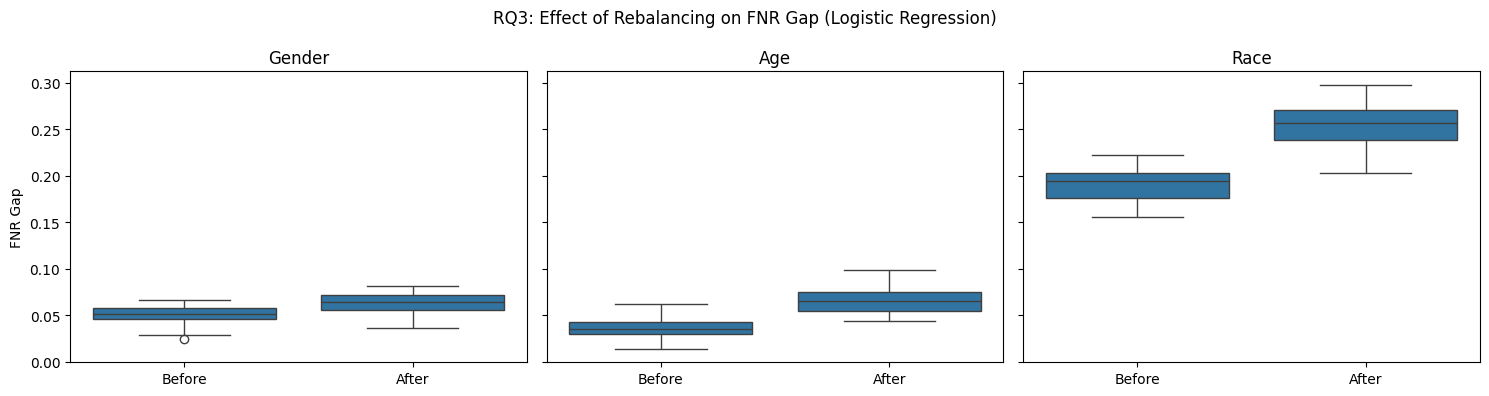

In [70]:
plot_fnr_boxplots(
    rq3_logistic['gaps_before'],
    rq3_logistic['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Logistic Regression)'
)

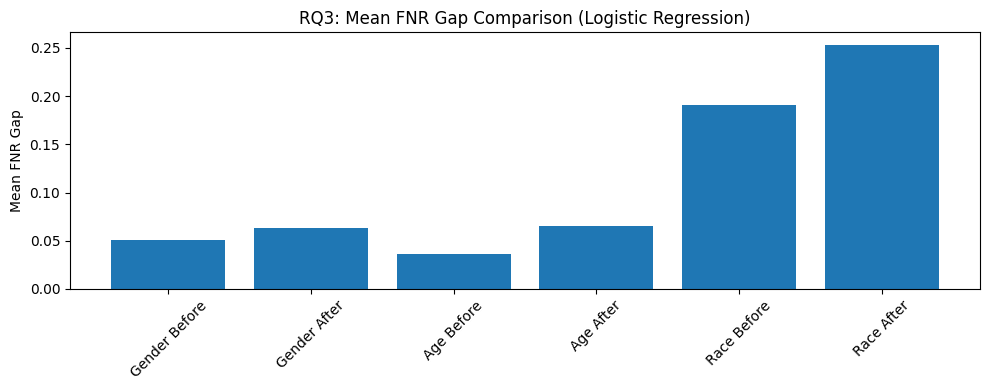

In [71]:
plot_fnr_means(
    rq3_logistic['gaps_before'],
    rq3_logistic['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Logistic Regression)'
)

In [72]:
# Random Forest
rq3_rf = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [73]:
run_paired_test(rq3_rf['gaps_before']['gender'], rq3_rf['gaps_after']['gender'], "Gender RQ3 RF")
run_paired_test(rq3_rf['gaps_before']['age'], rq3_rf['gaps_after']['age'], "Age RQ3 RF")
run_paired_test(rq3_rf['gaps_before']['race'], rq3_rf['gaps_after']['race'], "Race RQ3 RF")

Gender RQ3 RF p-value: 0.04012176043000587
Gender RQ3 RF mean BEFORE: 0.043628261322335674
Gender RQ3 RF mean AFTER : 0.04087701007280603
Gender RQ3 RF valid runs : 35
----------------------------------------
Age RQ3 RF p-value: 0.26254443947981637
Age RQ3 RF mean BEFORE: 0.010335411684964674
Age RQ3 RF mean AFTER : 0.00834755042257449
Age RQ3 RF valid runs : 35
----------------------------------------
Race RQ3 RF p-value: 1.086893358165076e-08
Race RQ3 RF mean BEFORE: 0.16208116467190758
Race RQ3 RF mean AFTER : 0.1412314601833161
Race RQ3 RF valid runs : 35
----------------------------------------


{'label': 'Race RQ3 RF',
 'p_value': np.float64(1.086893358165076e-08),
 'mean_before': np.float64(0.16208116467190758),
 'mean_after': np.float64(0.1412314601833161),
 'valid_runs': 35}

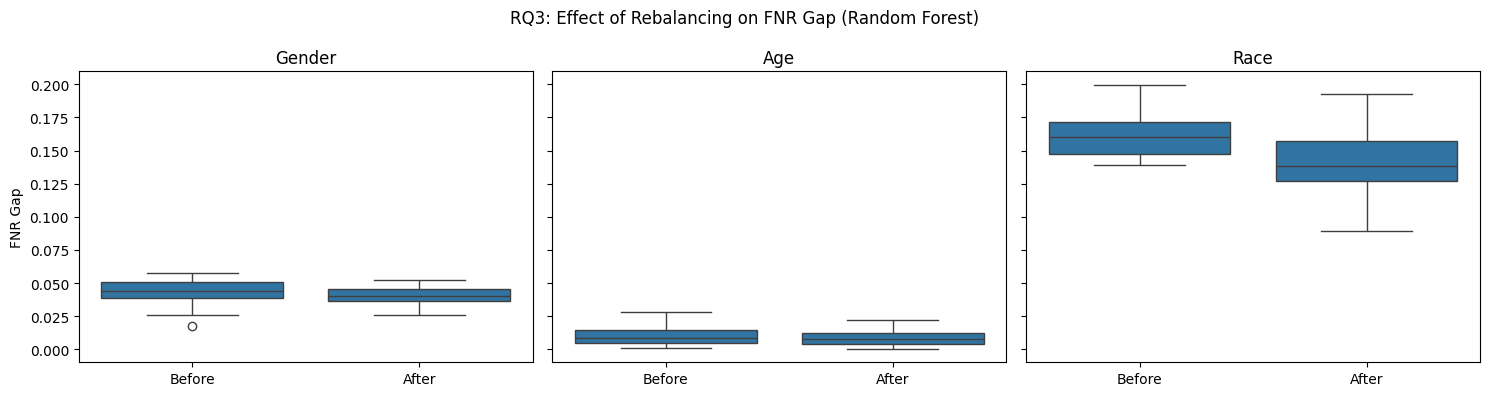

In [74]:
plot_fnr_boxplots(
    rq3_rf['gaps_before'],
    rq3_rf['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Random Forest)'
)

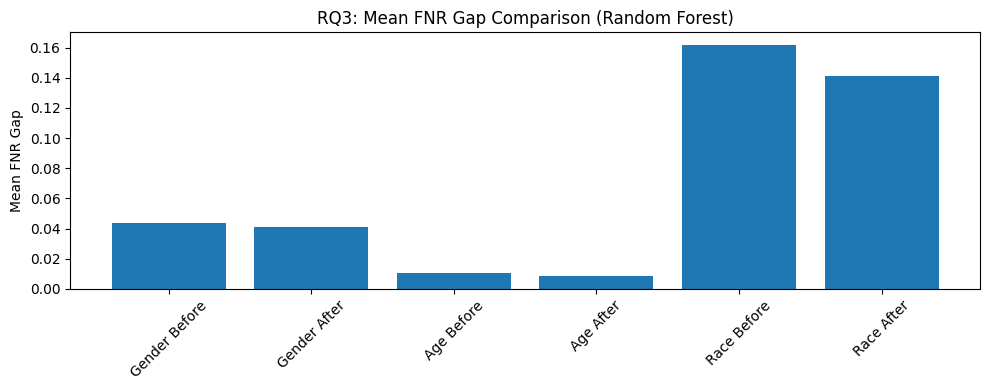

In [75]:
plot_fnr_means(
    rq3_rf['gaps_before'],
    rq3_rf['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Random Forest)'
)

In [76]:
# Gradient Boosting
rq3_gb = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='gradient_boosting',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [77]:
run_paired_test(rq3_gb['gaps_before']['gender'], rq3_gb['gaps_after']['gender'], "Gender RQ3 GB")
run_paired_test(rq3_gb['gaps_before']['age'], rq3_gb['gaps_after']['age'], "Age RQ3 GB")
run_paired_test(rq3_gb['gaps_before']['race'], rq3_gb['gaps_after']['race'], "Race RQ3 GB")

Gender RQ3 GB p-value: 0.0003541036813540629
Gender RQ3 GB mean BEFORE: 0.03514244132629089
Gender RQ3 GB mean AFTER : 0.04090731741948208
Gender RQ3 GB valid runs : 35
----------------------------------------
Age RQ3 GB p-value: 3.8243625189091434e-09
Age RQ3 GB mean BEFORE: 0.007429924235075516
Age RQ3 GB mean AFTER : 0.02416004188339782
Age RQ3 GB valid runs : 35
----------------------------------------
Race RQ3 GB p-value: 2.688522550263838e-06
Race RQ3 GB mean BEFORE: 0.16151145113435816
Race RQ3 GB mean AFTER : 0.1767354449369953
Race RQ3 GB valid runs : 35
----------------------------------------


{'label': 'Race RQ3 GB',
 'p_value': np.float64(2.688522550263838e-06),
 'mean_before': np.float64(0.16151145113435816),
 'mean_after': np.float64(0.1767354449369953),
 'valid_runs': 35}

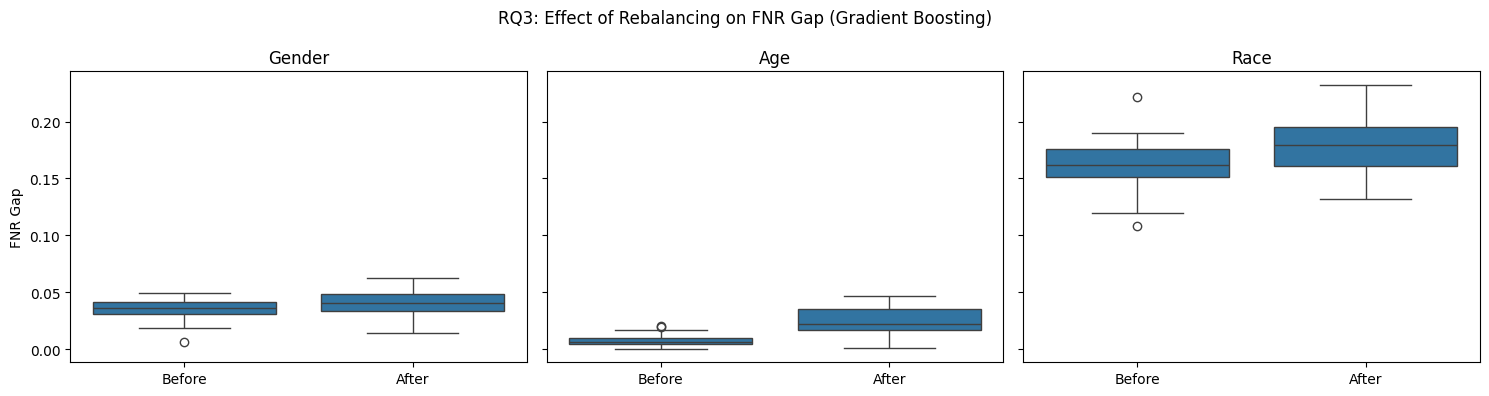

In [78]:
plot_fnr_boxplots(
    rq3_gb['gaps_before'],
    rq3_gb['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Gradient Boosting)'
)

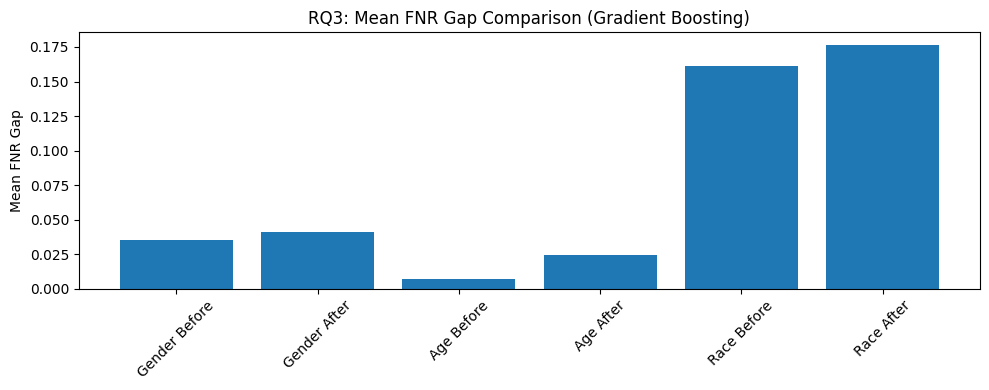

In [79]:
plot_fnr_means(
    rq3_gb['gaps_before'],
    rq3_gb['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Gradient Boosting)'
)

In [80]:
summary_rq3 = pd.concat([
    summarize_experiment(rq3_logistic, "Logistic_RQ3"),
    summarize_experiment(rq3_rf, "RandomForest_RQ3"),
    summarize_experiment(rq3_gb, "GradientBoosting_RQ3")
], ignore_index=True)

summary_rq3

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Logistic_RQ3,logistic,oversample,FNR Gap,Gender,0.05083,0.06334,0.01251,0.00000,35
1,Logistic_RQ3,logistic,oversample,FNR Gap,Age,0.03583,0.06520,0.02937,0.00000,35
2,Logistic_RQ3,logistic,oversample,FNR Gap,Race,0.19111,0.25356,0.06244,0.00000,35
3,Logistic_RQ3,logistic,oversample,AUC,Overall,0.65502,0.65488,-0.00014,0.00439,35
4,RandomForest_RQ3,random_forest,oversample,FNR Gap,Gender,0.04363,0.04088,-0.00275,0.04012,35
5,RandomForest_RQ3,random_forest,oversample,FNR Gap,Age,0.01034,0.00835,-0.00199,0.26254,35
6,RandomForest_RQ3,random_forest,oversample,FNR Gap,Race,0.16208,0.14123,-0.02085,0.00000,35
7,RandomForest_RQ3,random_forest,oversample,AUC,Overall,0.63427,0.63107,-0.00319,0.00000,35
8,GradientBoosting_RQ3,gradient_boosting,oversample,FNR Gap,Gender,0.03514,0.04091,0.00576,0.00035,35
9,GradientBoosting_RQ3,gradient_boosting,oversample,FNR Gap,Age,0.00743,0.02416,0.01673,0.00000,35


# Research question #4 : Effectiveness of Bias Mitigation

In [81]:
rq4_logistic_cw = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)

In [82]:
run_paired_test(rq4_logistic_cw['gaps_before']['gender'], rq4_logistic_cw['gaps_after']['gender'], "Gender RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['gaps_before']['age'], rq4_logistic_cw['gaps_after']['age'], "Age RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['gaps_before']['race'], rq4_logistic_cw['gaps_after']['race'], "Race RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['auc_before'], rq4_logistic_cw['auc_after'], "AUC RQ4 Logistic ClassWeight")

Gender RQ4 Logistic ClassWeight p-value: 1.4189889251979555e-11
Gender RQ4 Logistic ClassWeight mean BEFORE: 0.050827823067450394
Gender RQ4 Logistic ClassWeight mean AFTER : 0.06263546786736343
Gender RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
Age RQ4 Logistic ClassWeight p-value: 3.2716581148953527e-25
Age RQ4 Logistic ClassWeight mean BEFORE: 0.035830296865070846
Age RQ4 Logistic ClassWeight mean AFTER : 0.06600661106311322
Age RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
Race RQ4 Logistic ClassWeight p-value: 2.8926944549365894e-30
Race RQ4 Logistic ClassWeight mean BEFORE: 0.19111308884870765
Race RQ4 Logistic ClassWeight mean AFTER : 0.2512353489237745
Race RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
AUC RQ4 Logistic ClassWeight p-value: 1.328561991401619e-10
AUC RQ4 Logistic ClassWeight mean BEFORE: 0.6550225322042216
AUC RQ4 Logistic ClassWeight mean AFTER : 0.65510

{'label': 'AUC RQ4 Logistic ClassWeight',
 'p_value': np.float64(1.328561991401619e-10),
 'mean_before': np.float64(0.6550225322042216),
 'mean_after': np.float64(0.6551055135920607),
 'valid_runs': 35}

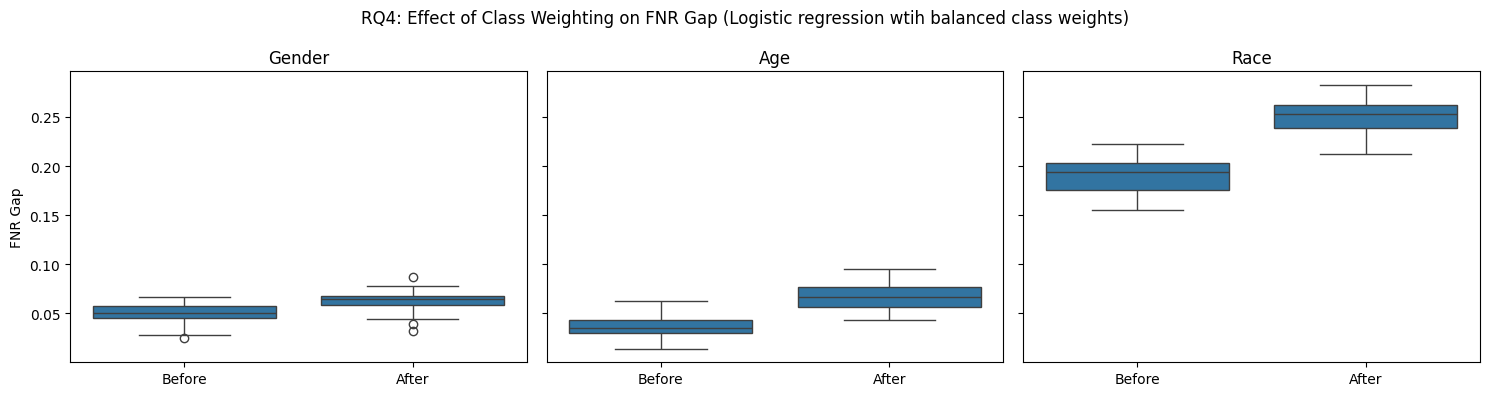

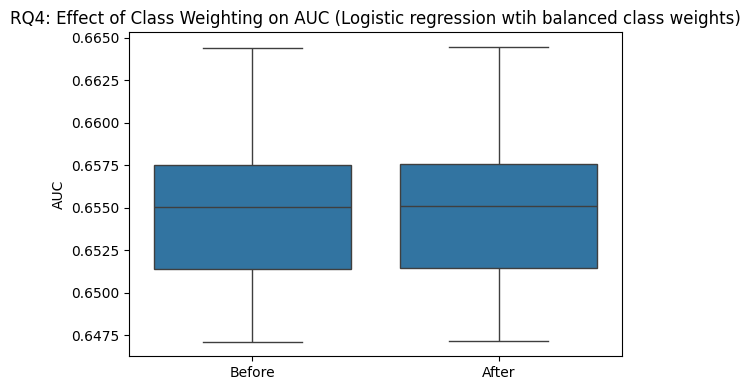

In [83]:
plot_fnr_boxplots(
    rq4_logistic_cw['gaps_before'],
    rq4_logistic_cw['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih balanced class weights)'
)

plot_auc_boxplot(
    rq4_logistic_cw['auc_before'],
    rq4_logistic_cw['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih balanced class weights)'
)

In [84]:
rq4_logistic_os = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [85]:
run_paired_test(rq4_logistic_os['gaps_before']['gender'], rq4_logistic_os['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['gaps_before']['age'], rq4_logistic_os['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['gaps_before']['race'], rq4_logistic_os['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['auc_before'], rq4_logistic_os['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 2.3582074148864204e-08
Gender RQ4 Logistic Oversample mean BEFORE: 0.050827823067450394
Gender RQ4 Logistic Oversample mean AFTER : 0.06333947431780583
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 1.2451875994793787e-18
Age RQ4 Logistic Oversample mean BEFORE: 0.035830296865070846
Age RQ4 Logistic Oversample mean AFTER : 0.06519977389711336
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 6.883129155573233e-25
Race RQ4 Logistic Oversample mean BEFORE: 0.19111308884870765
Race RQ4 Logistic Oversample mean AFTER : 0.2535579346830661
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 0.004389946305937191
AUC RQ4 Logistic Oversample mean BEFORE: 0.6550225322042216
AUC RQ4 Logistic Oversample mean AFTER : 0.6548789008247847
AUC R

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(0.004389946305937191),
 'mean_before': np.float64(0.6550225322042216),
 'mean_after': np.float64(0.6548789008247847),
 'valid_runs': 35}

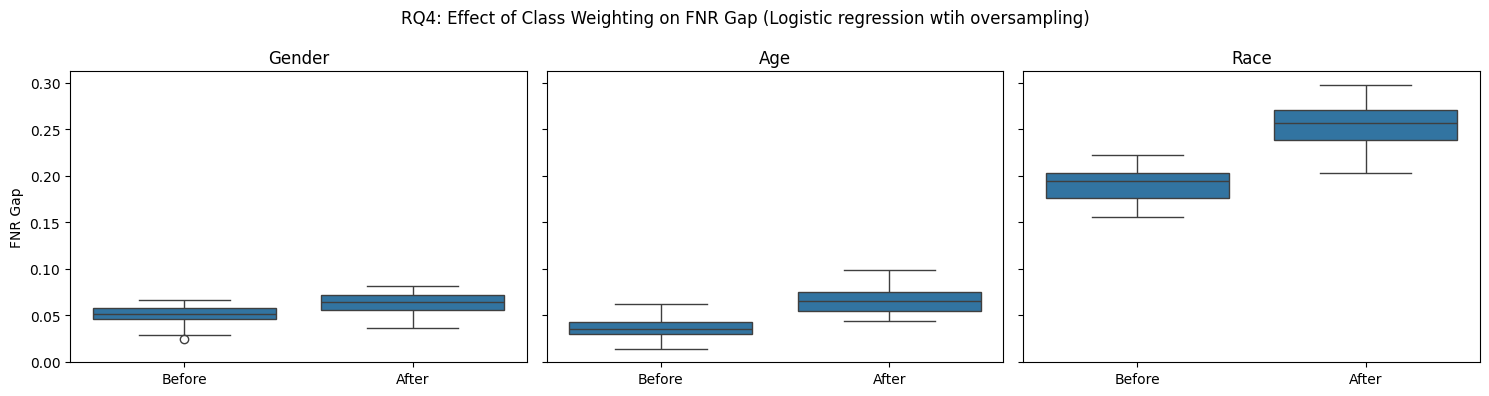

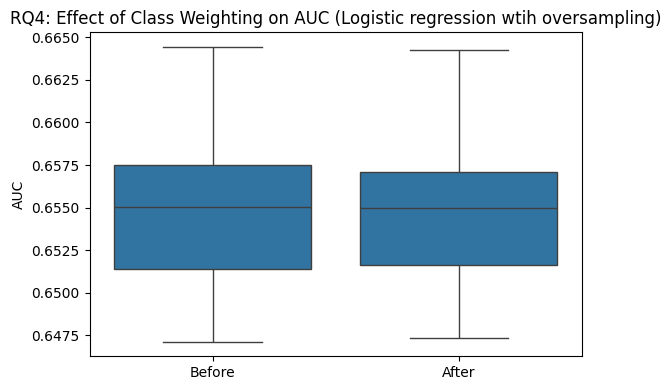

In [86]:
plot_fnr_boxplots(
    rq4_logistic_os['gaps_before'],
    rq4_logistic_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih oversampling)'
)

plot_auc_boxplot(
    rq4_logistic_os['auc_before'],
    rq4_logistic_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih oversampling)'
)

In [87]:
rq4_rf_cw = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)

In [88]:
run_paired_test(rq4_rf_cw['gaps_before']['gender'], rq4_rf_cw['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_rf_cw['gaps_before']['age'], rq4_rf_cw['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_rf_cw['gaps_before']['race'], rq4_rf_cw['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_rf_cw['auc_before'], rq4_rf_cw['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 0.5517020577543543
Gender RQ4 Logistic Oversample mean BEFORE: 0.04363382754648752
Gender RQ4 Logistic Oversample mean AFTER : 0.044269303020514315
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 0.7551801176831483
Age RQ4 Logistic Oversample mean BEFORE: 0.010341693881220484
Age RQ4 Logistic Oversample mean AFTER : 0.010614120565002591
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 0.654269691101198
Race RQ4 Logistic Oversample mean BEFORE: 0.1620851606759036
Race RQ4 Logistic Oversample mean AFTER : 0.16287629852553007
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 0.2361703608742167
AUC RQ4 Logistic Oversample mean BEFORE: 0.634266101287873
AUC RQ4 Logistic Oversample mean AFTER : 0.6344862385719742
AUC RQ4 Logistic Ov

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(0.2361703608742167),
 'mean_before': np.float64(0.634266101287873),
 'mean_after': np.float64(0.6344862385719742),
 'valid_runs': 35}

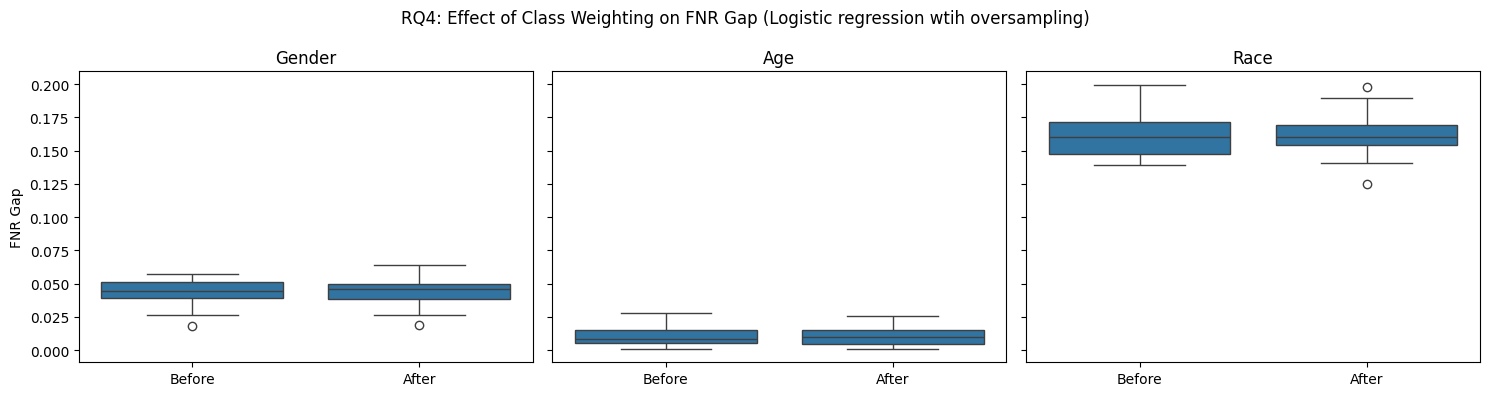

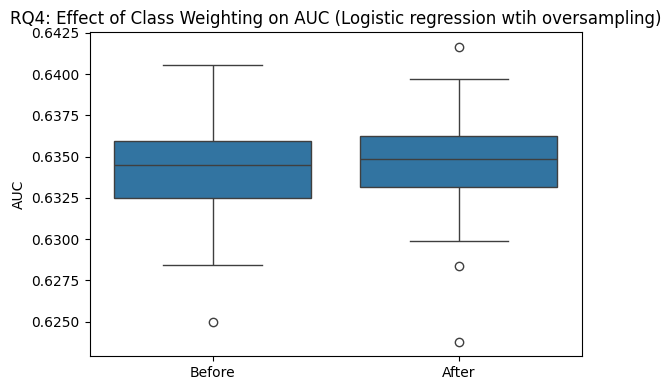

In [89]:
plot_fnr_boxplots(
    rq4_rf_cw['gaps_before'],
    rq4_rf_cw['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih oversampling)'
)

plot_auc_boxplot(
    rq4_rf_cw['auc_before'],
    rq4_rf_cw['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih oversampling)'
)

In [90]:
rq4_rf_os = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [91]:
run_paired_test(rq4_rf_os['gaps_before']['gender'], rq4_rf_os['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_rf_os['gaps_before']['age'], rq4_rf_os['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_rf_os['gaps_before']['race'], rq4_rf_os['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_rf_os['auc_before'], rq4_rf_os['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 0.03978175758989073
Gender RQ4 Logistic Oversample mean BEFORE: 0.04363382754648752
Gender RQ4 Logistic Oversample mean AFTER : 0.04087701007280603
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 0.2613353259767722
Age RQ4 Logistic Oversample mean BEFORE: 0.010341693881220484
Age RQ4 Logistic Oversample mean AFTER : 0.00834755042257449
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 1.0758878477082317e-08
Race RQ4 Logistic Oversample mean BEFORE: 0.1620851606759036
Race RQ4 Logistic Oversample mean AFTER : 0.1412314601833161
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 4.4403952335926054e-14
AUC RQ4 Logistic Oversample mean BEFORE: 0.6342660968469073
AUC RQ4 Logistic Oversample mean AFTER : 0.6310711524300969
AUC RQ4 Log

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(4.4403952335926054e-14),
 'mean_before': np.float64(0.6342660968469073),
 'mean_after': np.float64(0.6310711524300969),
 'valid_runs': 35}

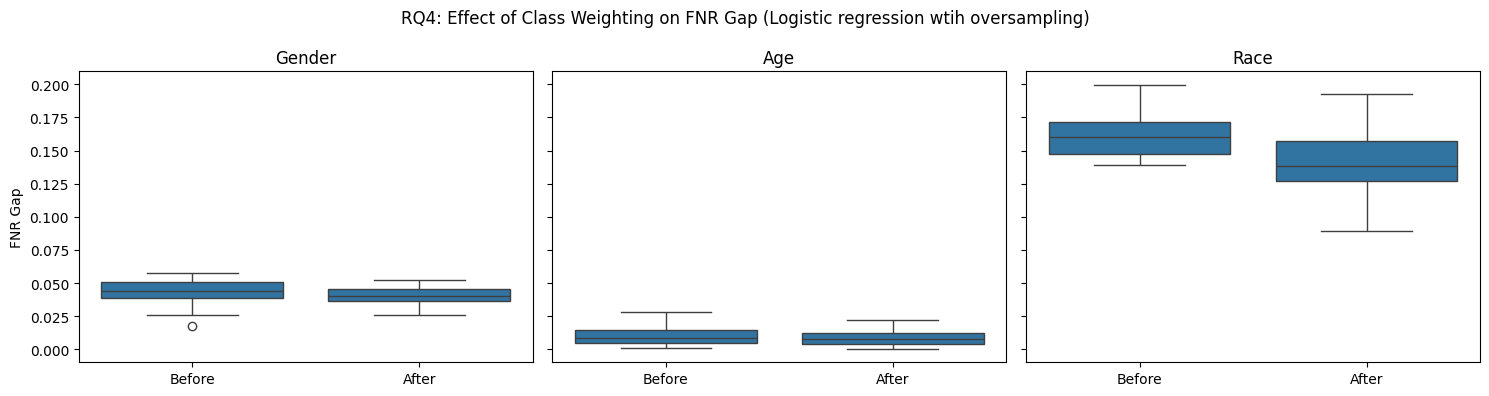

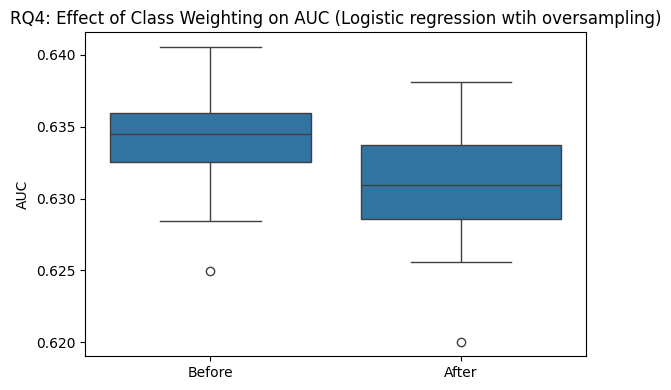

In [92]:
plot_fnr_boxplots(
    rq4_rf_os['gaps_before'],
    rq4_rf_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih oversampling)'
)

plot_auc_boxplot(
    rq4_rf_os['auc_before'],
    rq4_rf_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih oversampling)'
)

In [93]:
rq4_gb_os = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='gradient_boosting',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [94]:
run_paired_test(rq4_gb_os['gaps_before']['gender'], rq4_gb_os['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_gb_os['gaps_before']['age'], rq4_gb_os['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_gb_os['gaps_before']['race'], rq4_gb_os['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_gb_os['auc_before'], rq4_gb_os['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 0.0003541036813540629
Gender RQ4 Logistic Oversample mean BEFORE: 0.03514244132629089
Gender RQ4 Logistic Oversample mean AFTER : 0.04090731741948208
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 3.8243625189091434e-09
Age RQ4 Logistic Oversample mean BEFORE: 0.007429924235075516
Age RQ4 Logistic Oversample mean AFTER : 0.02416004188339782
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 2.688522550263838e-06
Race RQ4 Logistic Oversample mean BEFORE: 0.16151145113435816
Race RQ4 Logistic Oversample mean AFTER : 0.1767354449369953
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 0.0007129295247649185
AUC RQ4 Logistic Oversample mean BEFORE: 0.6648771947861603
AUC RQ4 Logistic Oversample mean AFTER : 0.6644423828833823
AUC RQ

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(0.0007129295247649185),
 'mean_before': np.float64(0.6648771947861603),
 'mean_after': np.float64(0.6644423828833823),
 'valid_runs': 35}

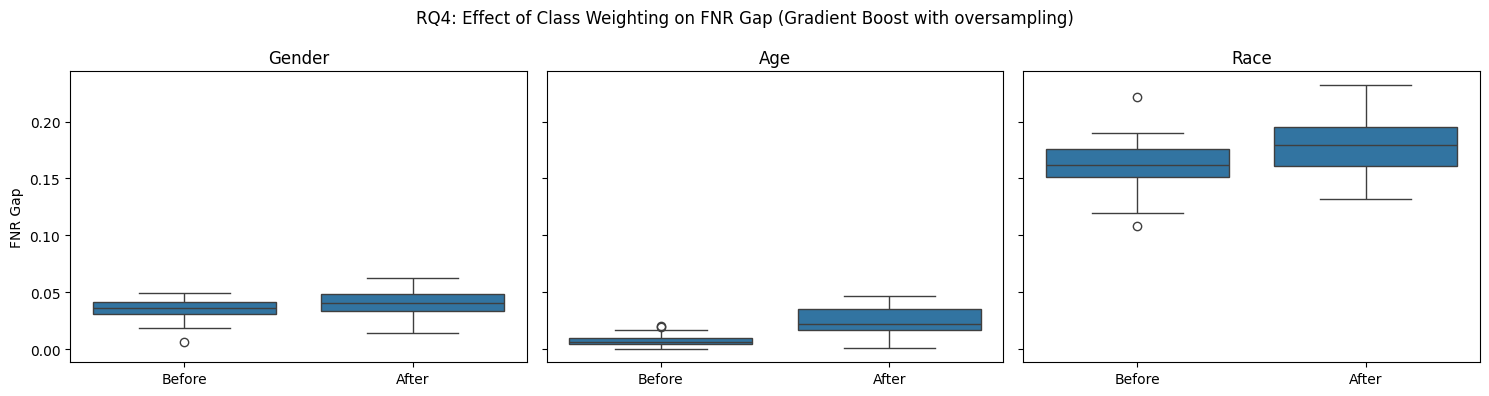

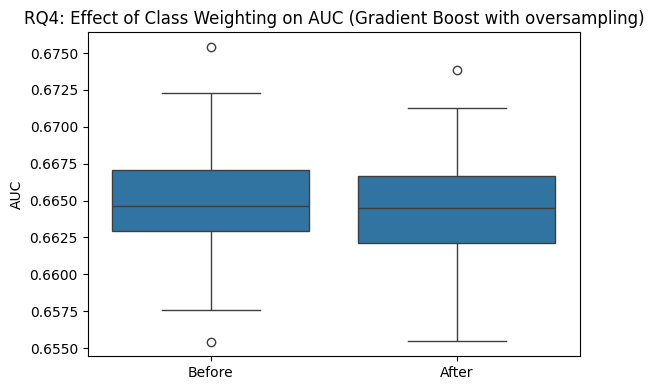

In [95]:
plot_fnr_boxplots(
    rq4_gb_os['gaps_before'],
    rq4_gb_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Gradient Boost with oversampling)'
)

plot_auc_boxplot(
    rq4_gb_os['auc_before'],
    rq4_gb_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Gradient Boost with oversampling)'
)

In [96]:
summary_rq4 = pd.concat([
    summarize_experiment(rq4_logistic_cw, "Logistic_RQ4 with class weights"),
    summarize_experiment(rq4_logistic_os, "Logistic_RQ4 with oversampling"),
    summarize_experiment(rq4_rf_cw, "RandomForest_RQ4 with class weights"),
    summarize_experiment(rq4_rf_os, "RandomForest_RQ4 with oversampling"),
    summarize_experiment(rq4_gb_os, "GradientBoost_RQ4 with oversampling")
], ignore_index=True)

summary_rq4

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Gender,0.05083,0.06264,0.01181,0.00000,35
1,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Age,0.03583,0.06601,0.03018,0.00000,35
2,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Race,0.19111,0.25124,0.06012,0.00000,35
3,Logistic_RQ4 with class weights,logistic,class_weight,AUC,Overall,0.65502,0.65511,0.00008,0.00000,35
4,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Gender,0.05083,0.06334,0.01251,0.00000,35
5,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Age,0.03583,0.06520,0.02937,0.00000,35
6,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Race,0.19111,0.25356,0.06244,0.00000,35
7,Logistic_RQ4 with oversampling,logistic,oversample,AUC,Overall,0.65502,0.65488,-0.00014,0.00439,35
8,RandomForest_RQ4 with class weights,random_forest,class_weight,FNR Gap,Gender,0.04363,0.04427,0.00064,0.55170,35
9,RandomForest_RQ4 with class weights,random_forest,class_weight,FNR Gap,Age,0.01034,0.01061,0.00027,0.75518,35
